# SHAP Analysis for Continuous Fraud Detection

This notebook provides **interactive SHAP analysis** integrated with the continuous learning framework.

## Purpose

1. **Understand Feature Importance**: Which features drive fraud predictions
2. **Monitor Drift**: Track feature importance changes across time windows
3. **Generate Adaptation Insights**: Feed SHAP results to the Adaptation Engine
4. **Review Continuous Learning**: Analyze model evolution over time

## Integration with Continuous Pipeline

| Component | Command | Description |
|-----------|---------|-------------|
| **Adaptation Engine** | `make analyze-adaptation` | Automated SHAP-based suggestions |
| **MLflow Tracking** | `make mlflow-ui` | Experiment tracking with SHAP artifacts |
| **Pipeline Status** | `make pipeline-status` | View recent drift and adaptation reports |

## Prerequisites

```bash
# Train models (all automatically use MLflow tracking and register models)
make train-baseline    # Baseline XGBoost with graph features
make train-sage        # SAGE hybrid model (GNN + XGBoost)
make train-hgt         # HGT hybrid model (GNN + XGBoost)
```

**Note**: This notebook now loads models from MLflow Model Registry instead of pickle files. All models are managed through MLflow and automatically registered during training.

See `docs/continuous_fraud_detection_framework.md` for the complete architecture.


In [1]:
import sys
import os
import importlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import polars as pl

# Import SHAP
import shap

# Set working directory to project root (assuming notebook is in notebooks/ subdirectory)
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
    os.chdir(project_root)
else:
    project_root = Path.cwd()

# Add project root to path
sys.path.insert(0, str(project_root))

# Import MLflow model loader (replaces old pickle-based loading)
from src.utils.mlflow_model_loader import (
    load_model_bundle,
    list_available_windows,
    get_window_info
)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
shap.initjs()

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Set MLflow experiment
mlflow.set_experiment("ppa-fraud-detection")

print(f"Project root: {project_root}")
print(f"Artifacts directory exists: {os.path.exists('artifacts')}")
print(f"✓ Using MLflow for model loading (replaces pickle files)")


/Users/dylan/Repos/ppa-fraud-notebook/.venv/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025/11/27 14:40:40 INFO mlflow.tracking.fluent: Experiment with name 'ppa-fraud-detection' does not exist. Creating a new experiment.


Project root: /Users/dylan/Repos/ppa-fraud-notebook
Artifacts directory exists: True
✓ Using MLflow for model loading (replaces pickle files)


### Available Models

First, let's check what models are available for analysis.


In [2]:
# List all available model types from MLflow
print("Available model types from MLflow:")
print("="*60)

# Common model types to check
model_types = ["baseline", "baseline_graph", "baseline_expanding", 
               "hybrid_hgt", "hybrid_gat", "hybrid_sage", "hybrid_hgt_rte"]

for model_type in model_types:
    windows = list_available_windows(model_type)
    if windows:
        print(f"\n{model_type}:")
        print(f"  Total windows: {len(windows)}")
        print(f"  Window range: {min(windows)} to {max(windows)}")
        print(f"  Latest window: {max(windows)}")
    else:
        # Check if model type exists in old pickle format (for migration reference)
        old_path = project_root / "artifacts" / "models" / model_type
        if old_path.exists():
            old_files = list(old_path.glob("model_window_*.pkl"))
            if old_files:
                print(f"\n{model_type}:")
                print(f"  ⚠️ Found {len(old_files)} legacy pickle files (migrate to MLflow)")


Available model types from MLflow:


## 1. Load Models

Load saved models from training runs. You can choose which model type and window to analyze.


In [ ]:
# Configuration
MODEL_TYPE = "baseline"  # Options: baseline, baseline_graph, hybrid_hgt, hybrid_sage, hybrid_gat, hybrid_hgt_rte
WINDOW_IDX = -1  # -1 for latest, or specify window index

# List available windows for this model type
available_windows = list_available_windows(MODEL_TYPE)

if not available_windows:
    print(f"⚠️ No MLflow runs found for model_type='{MODEL_TYPE}'")
    print(f"\nAvailable model types:")
    for mt in ["baseline", "baseline_graph", "hybrid_hgt", "hybrid_gat", "hybrid_sage"]:
        wins = list_available_windows(mt)
        if wins:
            print(f"  {mt}: {len(wins)} windows (range: {min(wins)}-{max(wins)})")
    print(f"\n💡 Train models first:")
    print(f"   make train-baseline  # Baseline XGBoost with graph features")
    print(f"   make train-sage     # SAGE hybrid model")
    print(f"   make train-hgt      # HGT hybrid model")
else:
    print(f"Found {len(available_windows)} windows for model_type='{MODEL_TYPE}'")
    print(f"Window range: {min(available_windows)} to {max(available_windows)}")
    
    # Determine which window to use
    if WINDOW_IDX == -1:
        selected_window = max(available_windows)
        print(f"\nSelected: Latest window ({selected_window})")
    else:
        if WINDOW_IDX in available_windows:
            selected_window = WINDOW_IDX
            print(f"\nSelected: Window {selected_window}")
        else:
            print(f"\n⚠️ Window {WINDOW_IDX} not found. Available: {min(available_windows)}-{max(available_windows)}")
            selected_window = max(available_windows)
            print(f"Using latest window ({selected_window}) instead")
    
    WINDOW_IDX = selected_window


⚠️ No MLflow runs found for model_type='baseline'

Available model types:

💡 Train models first: make train-mlflow


In [ ]:
# Load model from MLflow
print(f"Loading model from MLflow: {MODEL_TYPE}, window {WINDOW_IDX}...")
model_bundle = load_model_bundle(MODEL_TYPE, WINDOW_IDX)

if model_bundle is None:
    raise FileNotFoundError(
        f"Model not found in MLflow. Train models first:\n"
        f"  make train-baseline  # Baseline XGBoost with graph features\n"
        f"  make train-sage      # SAGE hybrid model\n"
        f"  make train-hgt       # HGT hybrid model"
    )

# Display model info
print("\n" + "="*60)
print("Model Information (from MLflow)")
print("="*60)
print(f"  MLflow Run ID: {model_bundle['run_id']}")
print(f"  Model URI: {model_bundle['model_uri']}")
print(f"  Window: {model_bundle['window_info']['window_start']} to {model_bundle['window_info']['window_end']}")
print(f"  Window Index: {model_bundle['window_info']['window_idx']}")
print(f"  Train size: {model_bundle['window_info']['train_size']:,}")
print(f"  Test size: {model_bundle['window_info']['test_size']:,}")
print(f"  Features: {len(model_bundle['features']) if model_bundle['features'] else 'N/A'}")
print(f"\nPerformance Metrics (from MLflow):")
for k, v in model_bundle['metrics'].items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Display sample feature names
if model_bundle['features']:
    print(f"\nSample features (first 10):")
    for i, feat in enumerate(model_bundle['features'][:10]):
        print(f"  {i+1}. {feat}")
    if len(model_bundle['features']) > 10:
        print(f"  ... and {len(model_bundle['features']) - 10} more")
else:
    print(f"\n⚠️ Feature names not available. Model loaded but features need to be extracted.")

# Note: Test data (X_test, y_test, y_pred) is not stored in MLflow
# We'll need to reconstruct it from window parameters for SHAP analysis
print(f"\n💡 Note: Test data needs to be loaded separately for SHAP analysis.")
print(f"   See next cell for loading test data based on window parameters.")


Loading model from MLflow: baseline, window -1...
No parent runs found for model_type='baseline'


FileNotFoundError: Model not found in MLflow. Train models first: make train-mlflow

## 2. Create SHAP Explainer

Initialize the SHAP explainer and compute SHAP values for all test instances.


In [ ]:
# Create SHAP explainer and compute SHAP values
print("Creating SHAP explainer (this may take a moment)...")

# Get feature names (use from model if available, otherwise from X_test)
feature_names = model_bundle.get('features', list(model_bundle['X_test'].columns))

# Create TreeExplainer for XGBoost
explainer_shap = shap.TreeExplainer(model_bundle['model'])

# Compute SHAP values (sample for speed - use subset if large)
X_test_sample = model_bundle['X_test']
if len(X_test_sample) > 1000:
    print(f"  Sampling 1000 instances from {len(X_test_sample):,} for SHAP computation...")
    sample_idx = np.random.choice(len(X_test_sample), 1000, replace=False)
    X_test_sample = X_test_sample.iloc[sample_idx]
    y_test_sample = model_bundle['y_test'][sample_idx]
    y_pred_sample = model_bundle['y_pred'][sample_idx]
else:
    y_test_sample = model_bundle['y_test']
    y_pred_sample = model_bundle['y_pred']

print("  Computing SHAP values...")
shap_values = explainer_shap.shap_values(X_test_sample)
expected_value = explainer_shap.expected_value

# Create a simple explainer object for compatibility
class SimpleExplainer:
    def __init__(self, shap_values, expected_value, X_test, y_test, y_pred, feature_names):
        self.shap_values = shap_values
        self.expected_value = expected_value
        self.X_test = X_test
        self.y_test = y_test
        self.y_pred = y_pred
        self.feature_names = feature_names
        
        # Create prediction type dataframe
        predicted_fraud = (y_pred >= 0.5).astype(int)
        y_true = y_test.astype(int)
        prediction_type = []
        for i in range(len(y_true)):
            if y_true[i] == 1 and predicted_fraud[i] == 1:
                prediction_type.append('TP')
            elif y_true[i] == 0 and predicted_fraud[i] == 0:
                prediction_type.append('TN')
            elif y_true[i] == 0 and predicted_fraud[i] == 1:
                prediction_type.append('FP')
            else:
                prediction_type.append('FN')
        
        self.df_test = X_test.copy()
        self.df_test['y_true'] = y_true
        self.df_test['y_pred'] = y_pred
        self.df_test['predicted_fraud'] = predicted_fraud
        self.df_test['prediction_type'] = prediction_type

explainer = SimpleExplainer(
    shap_values, expected_value, X_test_sample, 
    y_test_sample, y_pred_sample, feature_names
)

print(f"\n✓ SHAP explainer created successfully!")
print(f"  SHAP values shape: {explainer.shap_values.shape}")
print(f"  Expected value (base): {explainer.expected_value:.4f}")

# Display test set statistics
print(f"\nTest Set Statistics:")
print(f"  Total instances: {len(explainer.y_test):,}")
print(f"  Fraud cases (y=1): {explainer.y_test.sum():,} ({explainer.y_test.mean()*100:.2f}%)")
print(f"  Legitimate cases (y=0): {(explainer.y_test == 0).sum():,} ({(1-explainer.y_test.mean())*100:.2f}%)")
print(f"  Mean predicted probability: {explainer.y_pred.mean():.4f}")
print(f"  Predicted fraud (>=0.5): {(explainer.y_pred >= 0.5).sum():,}")

# Show prediction type distribution
pred_counts = pd.Series(explainer.df_test['prediction_type']).value_counts()
print(f"\nPrediction Type Distribution:")
for pred_type in ['TP', 'TN', 'FP', 'FN']:
    count = pred_counts.get(pred_type, 0)
    if count > 0:
        print(f"  {pred_type}: {count:,}")


Creating SHAP explainer (this may take a moment)...
Checking model integrity and fixing if needed...
✓ Model parameters normalized successfully
Initializing SHAP TreeExplainer...
Computing SHAP values...

✓ SHAP explainer created successfully!
  SHAP values shape: (3976, 14)
  Expected value (base): -0.0115

Test Set Statistics:
  Total instances: 3,976
  Fraud cases (y=1): 445 (11.19%)
  Legitimate cases (y=0): 3,531 (88.81%)
  Mean predicted probability: 0.2275
  Predicted fraud (>=0.5): 800

Prediction Type Distribution:
  TP: 353
  TN: 3,084
  FP: 447
  FN: 92


### 2.1 Test Data Preview

Preview of the test data that will be analyzed.


In [ ]:
# Display sample of test data
print("Sample Test Data:")
print("="*60)
sample_df = explainer.df_test[['y_true', 'y_pred', 'predicted_fraud', 'prediction_type']].head(10)
print(sample_df.to_string())

print(f"\n\nFull test data shape: {explainer.df_test.shape}")
print(f"Columns: {list(explainer.df_test.columns[:15])}..." if len(explainer.df_test.columns) > 15 else f"Columns: {list(explainer.df_test.columns)}")


Sample Test Data:
   y_true    y_pred  predicted_fraud prediction_type
0    True  0.935990                1              TP
1    True  0.933034                1              TP
2    True  0.910778                1              TP
3    True  0.894874                1              TP
4   False  0.001219                0              TN
5   False  0.002902                0              TN
6   False  0.815975                1              FP
7    True  0.894494                1              TP
8    True  0.902176                1              TP
9   False  0.280941                0              TN


Full test data shape: (3976, 18)
Columns: ['account_age_days', 'log_price', 'living_space', 'rooms', 'is_new', 'has_balcony', 'has_elevator', 'has_parking', 'bundle_period', 'bundle_tier_score', 'is_direct_payment', 'is_buy', 'latitude', 'longitude', 'y_true']...


## 3. Global Feature Importance

### 3.1 SHAP Summary Plot
Shows how each feature contributes to predictions across all instances.


Generating SHAP summary plot...


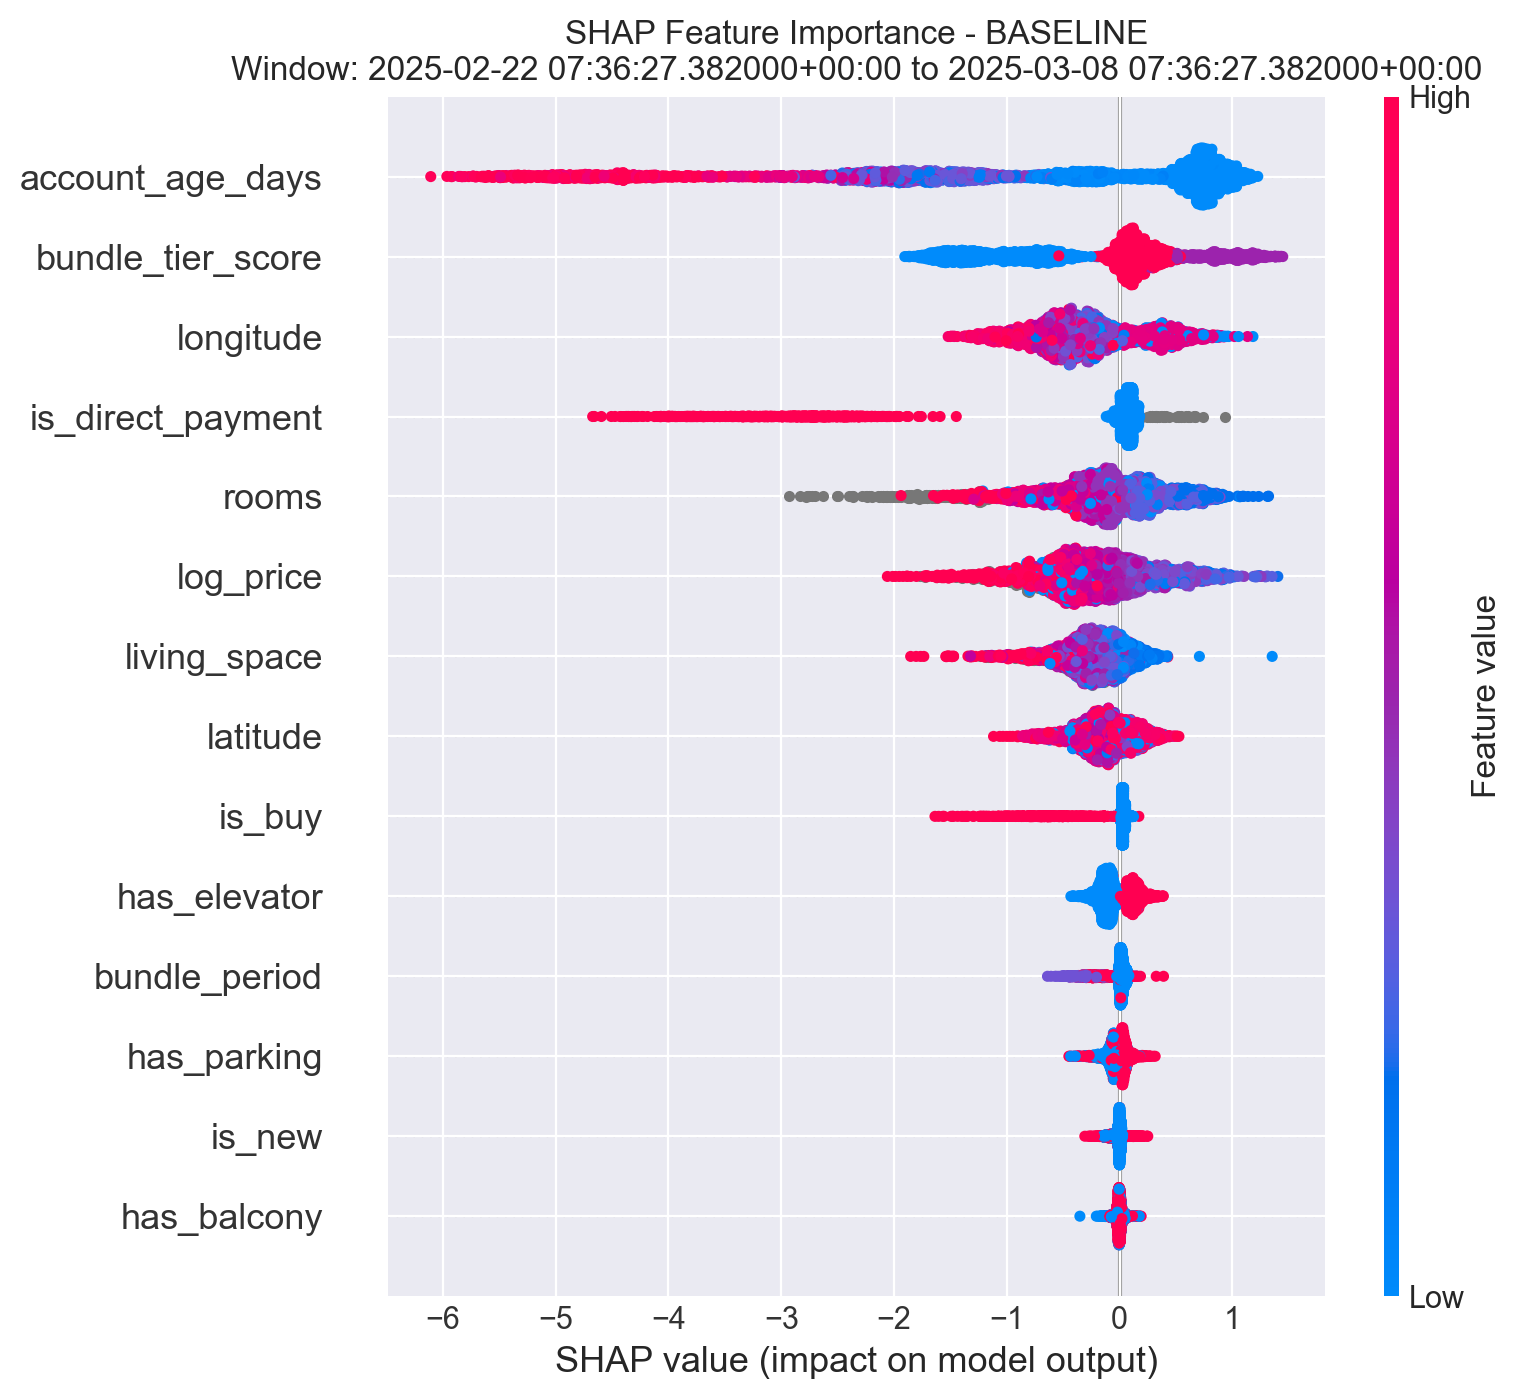

In [ ]:
# Summary plot (beeswarm)
fig = explainer.plot_summary(max_display=20, aggregate_embeddings=True)
plt.show()


### 3.2 Feature Importance Bar Chart
Mean absolute SHAP values showing overall feature importance.


Generating feature importance bar chart...


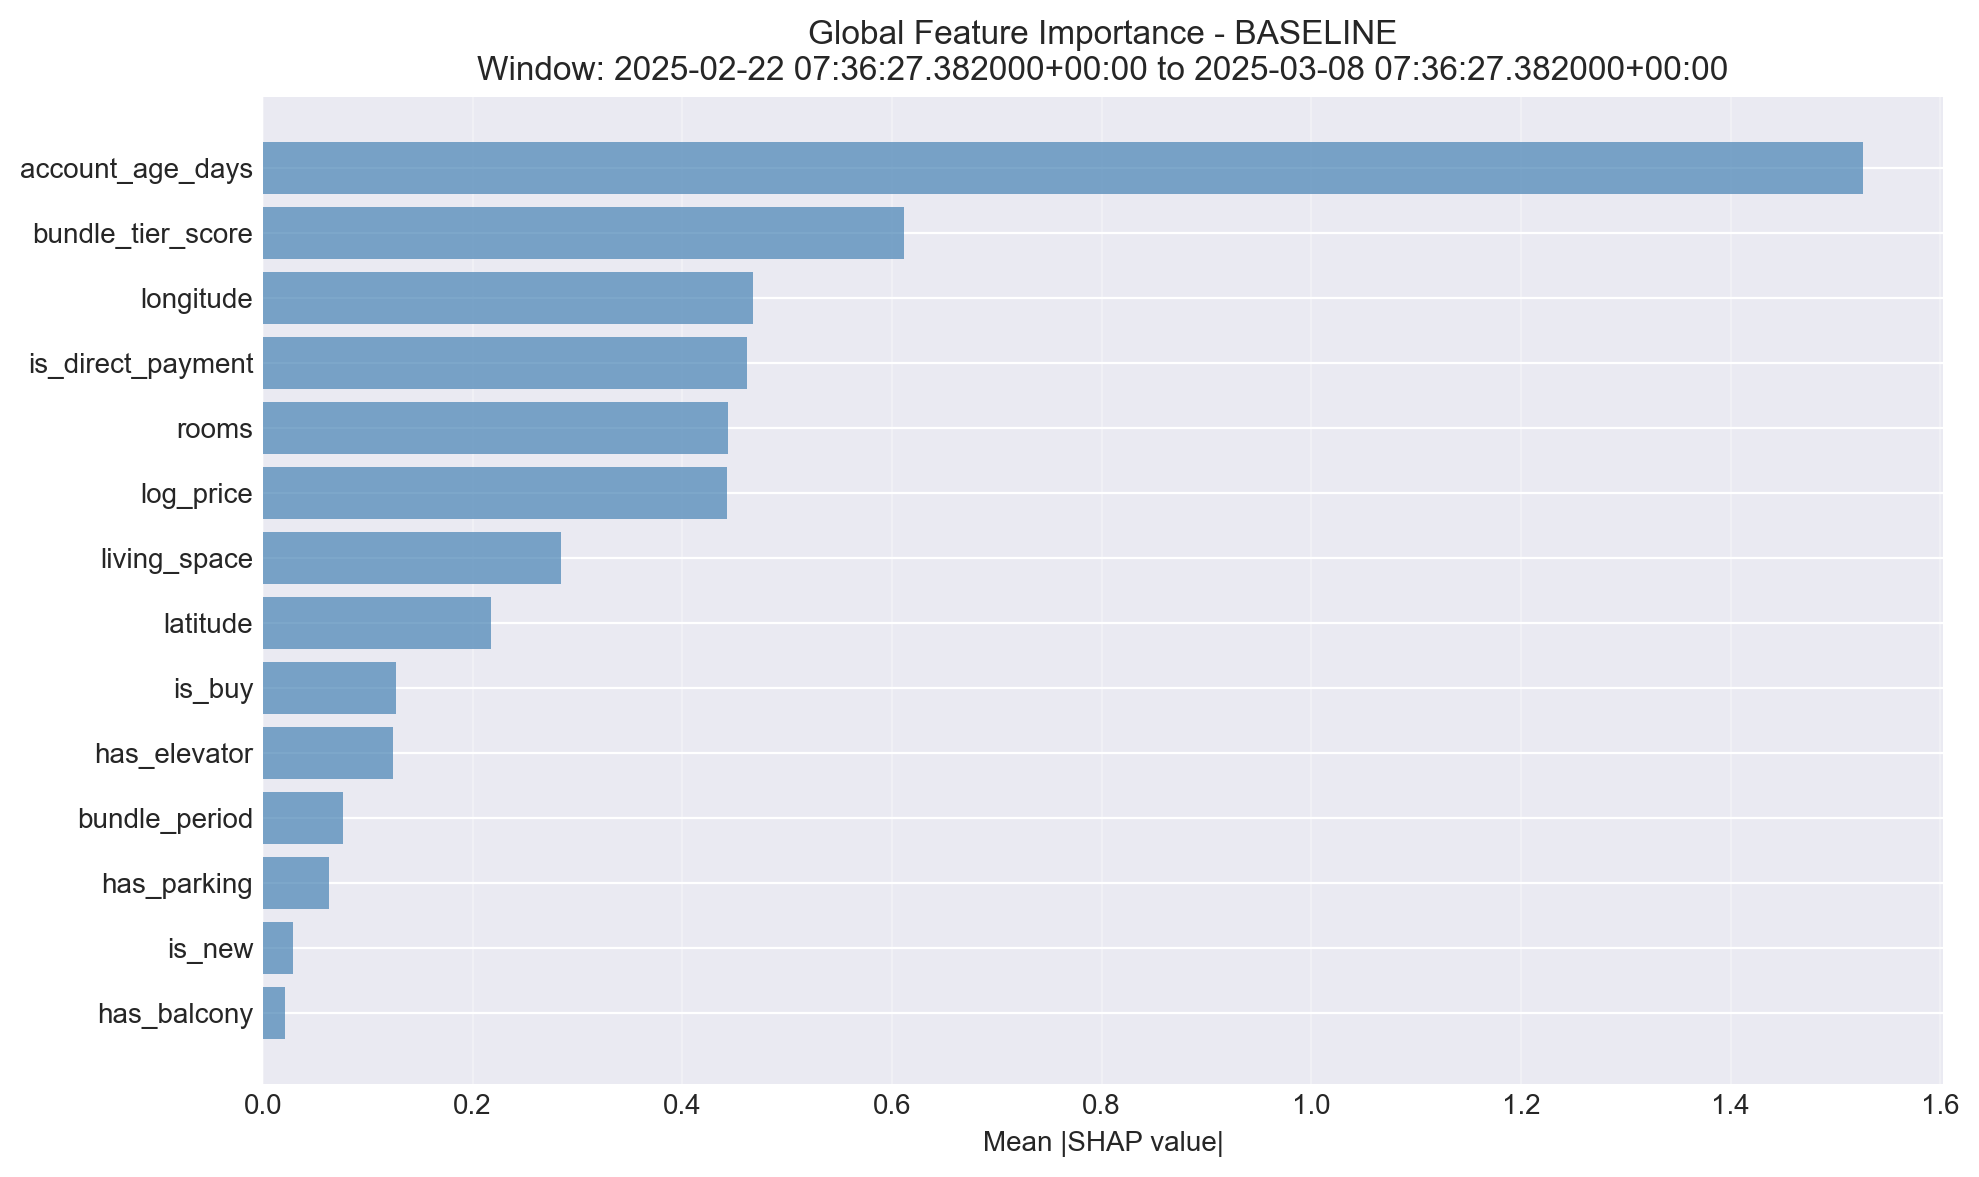

In [ ]:
fig = explainer.plot_feature_importance_bar(max_display=20, aggregate_embeddings=True)
plt.show()


### 3.3 Feature Importance Table


In [ ]:
importance_df = explainer.get_feature_importance_df(aggregate_embeddings=True)
print("Top 15 Most Important Features:")
importance_df.head(15)


Top 15 Most Important Features:


,feature,mean_abs_shap,mean_shap,std_shap,model_type,window_start,window_end
0,account_age_days,1.526271,-0.879927,1.853467,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00
9,bundle_tier_score,0.611837,-0.243985,0.762976,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00
13,longitude,0.467323,-0.282347,0.466671,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00
10,is_direct_payment,0.461928,-0.327903,1.056573,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00
3,rooms,0.443522,-0.186717,0.586157,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00
1,log_price,0.442969,-0.224934,0.507086,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00
2,living_space,0.284736,-0.236801,0.290945,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00
12,latitude,0.217116,-0.134857,0.241633,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00
11,is_buy,0.126678,-0.072879,0.268860,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00
6,has_elevator,0.123674,-0.027059,0.135922,baseline,2025-02-22 07:36:27.382000+00:00,2025-03-08 07:36:27.382000+00:00


## 4. Feature Dependence Analysis

Understand how individual features affect predictions and their interactions.


Analyzing dependence for: ['account_age_days', 'bundle_tier_score', 'longitude']
Generating dependence plot for account_age_days...


<Figure size 1000x600 with 0 Axes>

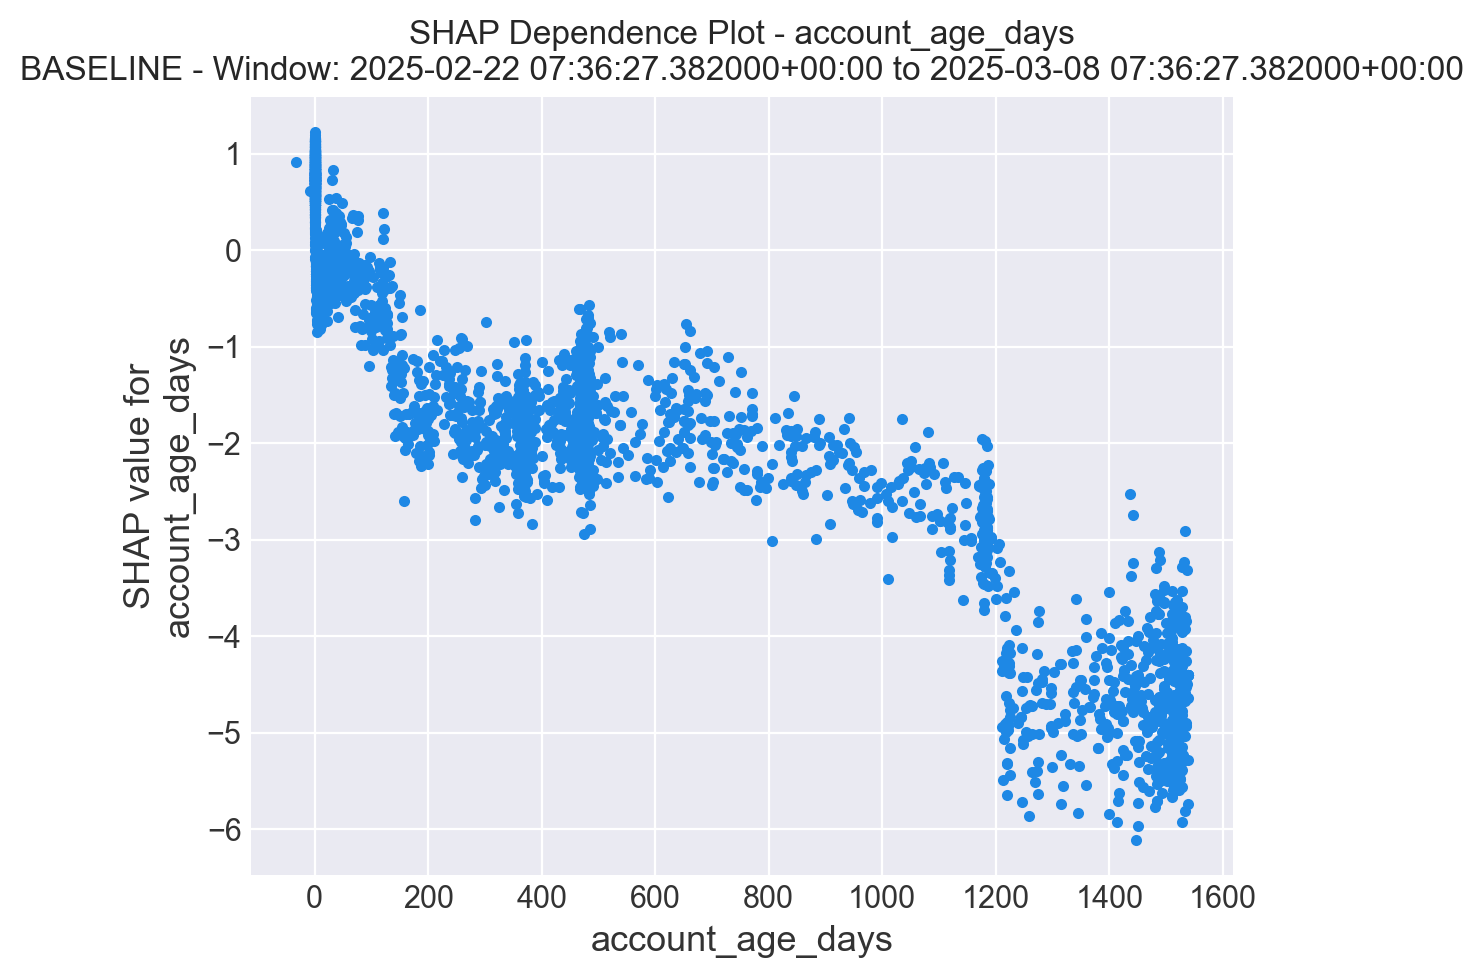

Generating dependence plot for bundle_tier_score...


<Figure size 1000x600 with 0 Axes>

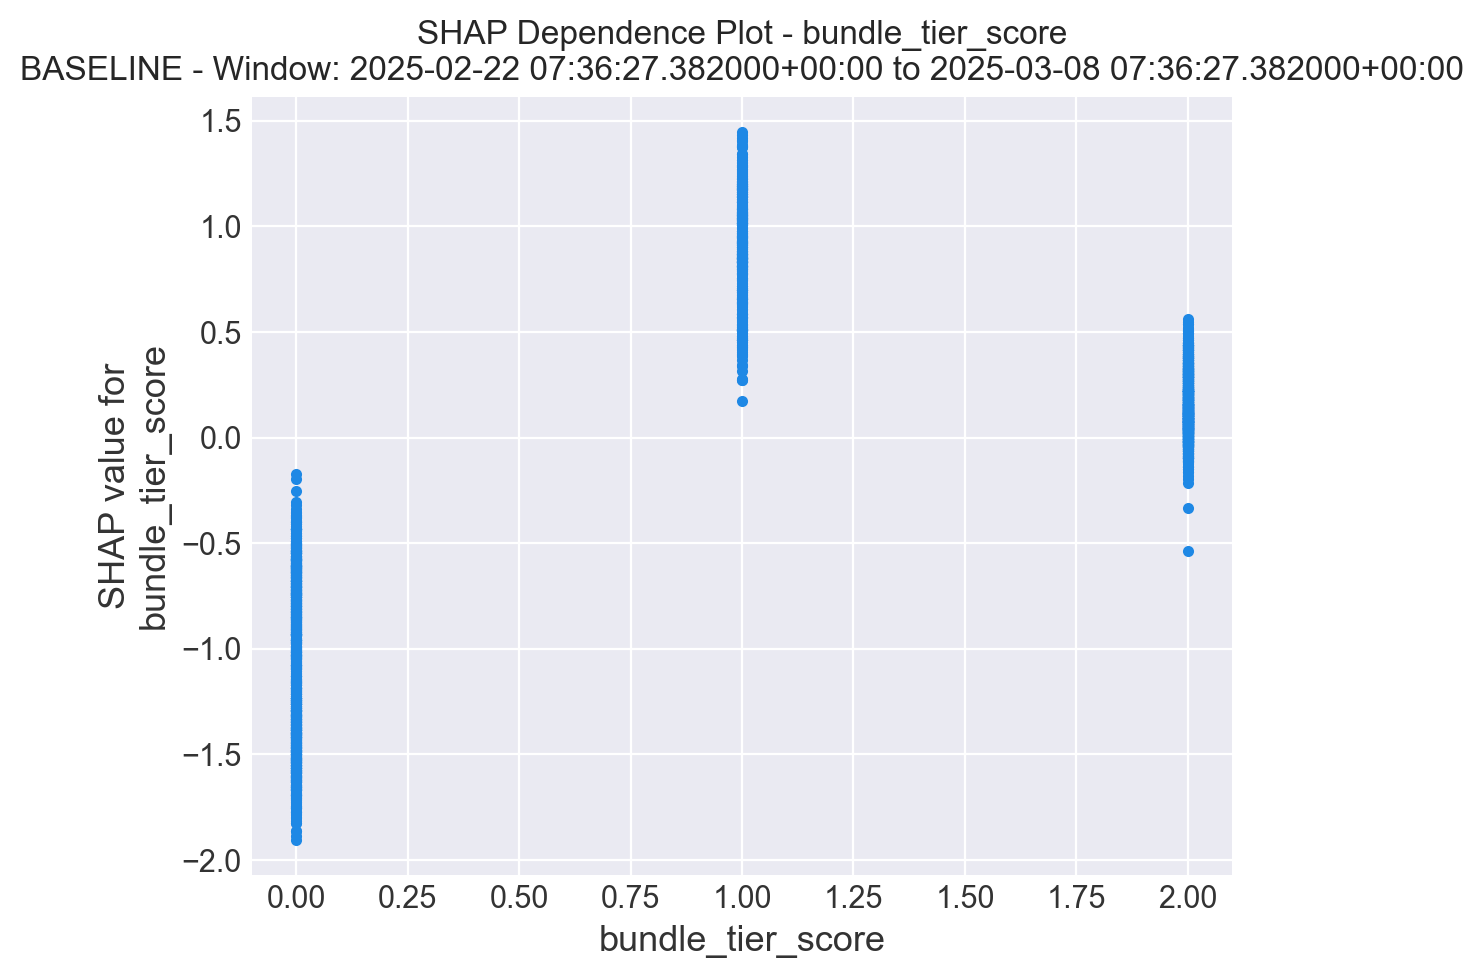

Generating dependence plot for longitude...


<Figure size 1000x600 with 0 Axes>

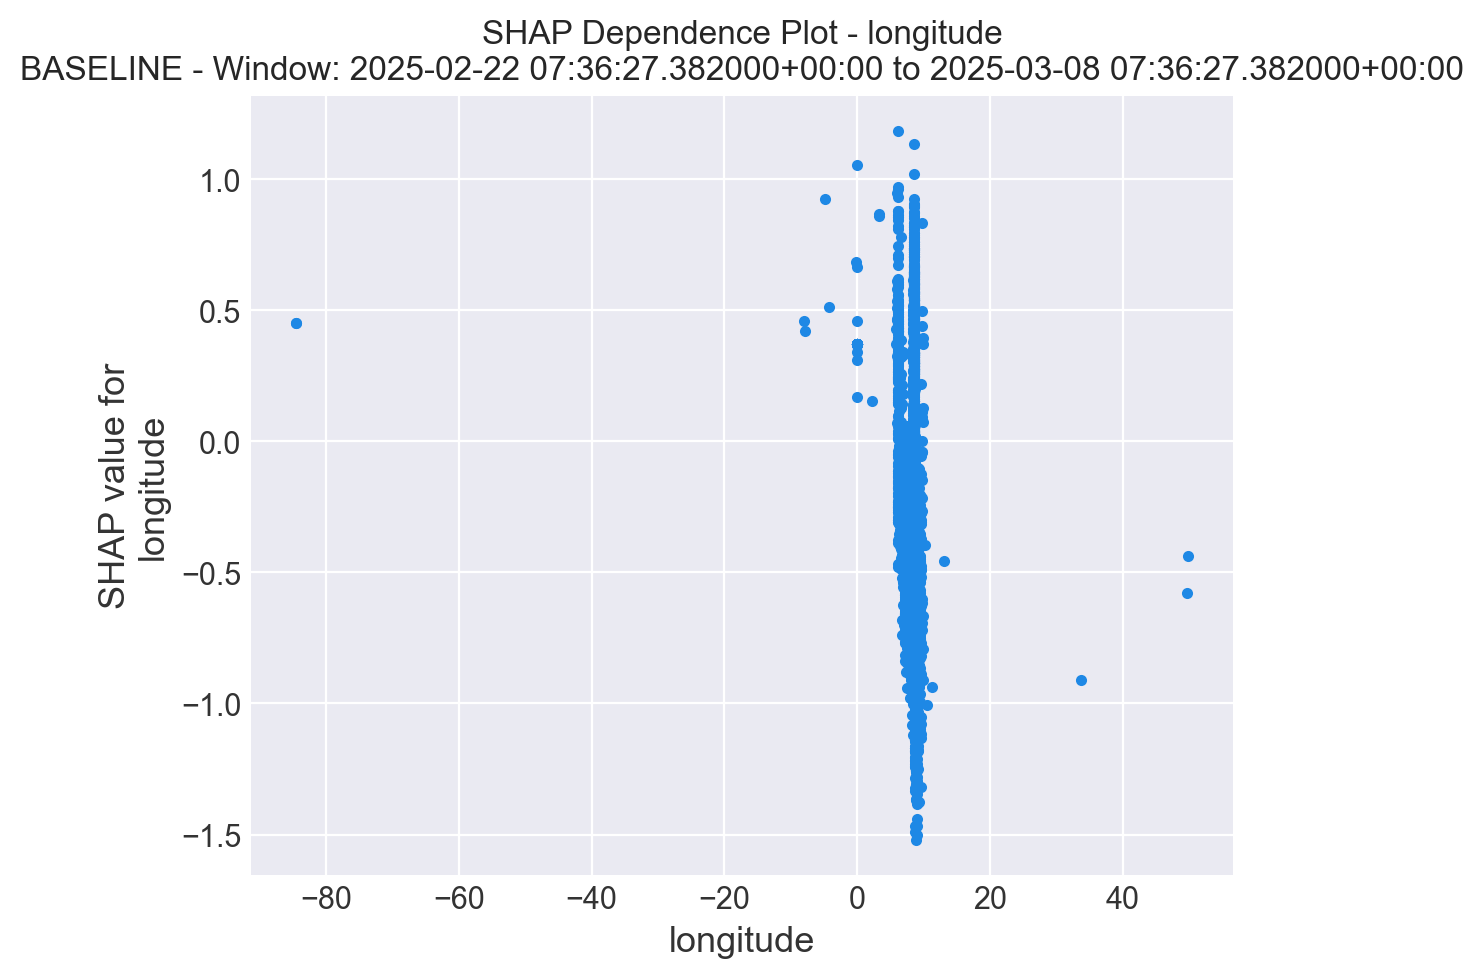

In [ ]:
# Select top features for dependence analysis
top_features = importance_df[importance_df['feature'] != 'GNN_embeddings'].head(3)['feature'].tolist()
print(f"Analyzing dependence for: {top_features}")

for feature in top_features:
    fig = explainer.plot_dependence(feature)
    plt.show()


## 5. Local Explanations: Individual Predictions

### 5.1 Understand False Positives
Why did the model incorrectly flag legitimate listings as fraud?


In [ ]:
# Count prediction types
pred_counts = explainer.df_test['prediction_type'].value_counts()
print("Prediction Distribution:")
print(pred_counts)
print(f"\nFalse Positive Rate: {pred_counts.get('FP', 0) / (pred_counts.get('TN', 0) + pred_counts.get('FP', 0)):.2%}")
print(f"False Negative Rate: {pred_counts.get('FN', 0) / (pred_counts.get('TP', 0) + pred_counts.get('FN', 0)):.2%}")


Prediction Distribution:
prediction_type
TN    3084
FP     447
TP     353
FN      92
Name: count, dtype: int64

False Positive Rate: 12.66%
False Negative Rate: 20.67%


Analyzing top 5 false positives out of 447 total

--- False Positive 1 (Index: 2620, Score: 0.9851) ---
Generating waterfall plot for instance 2620...


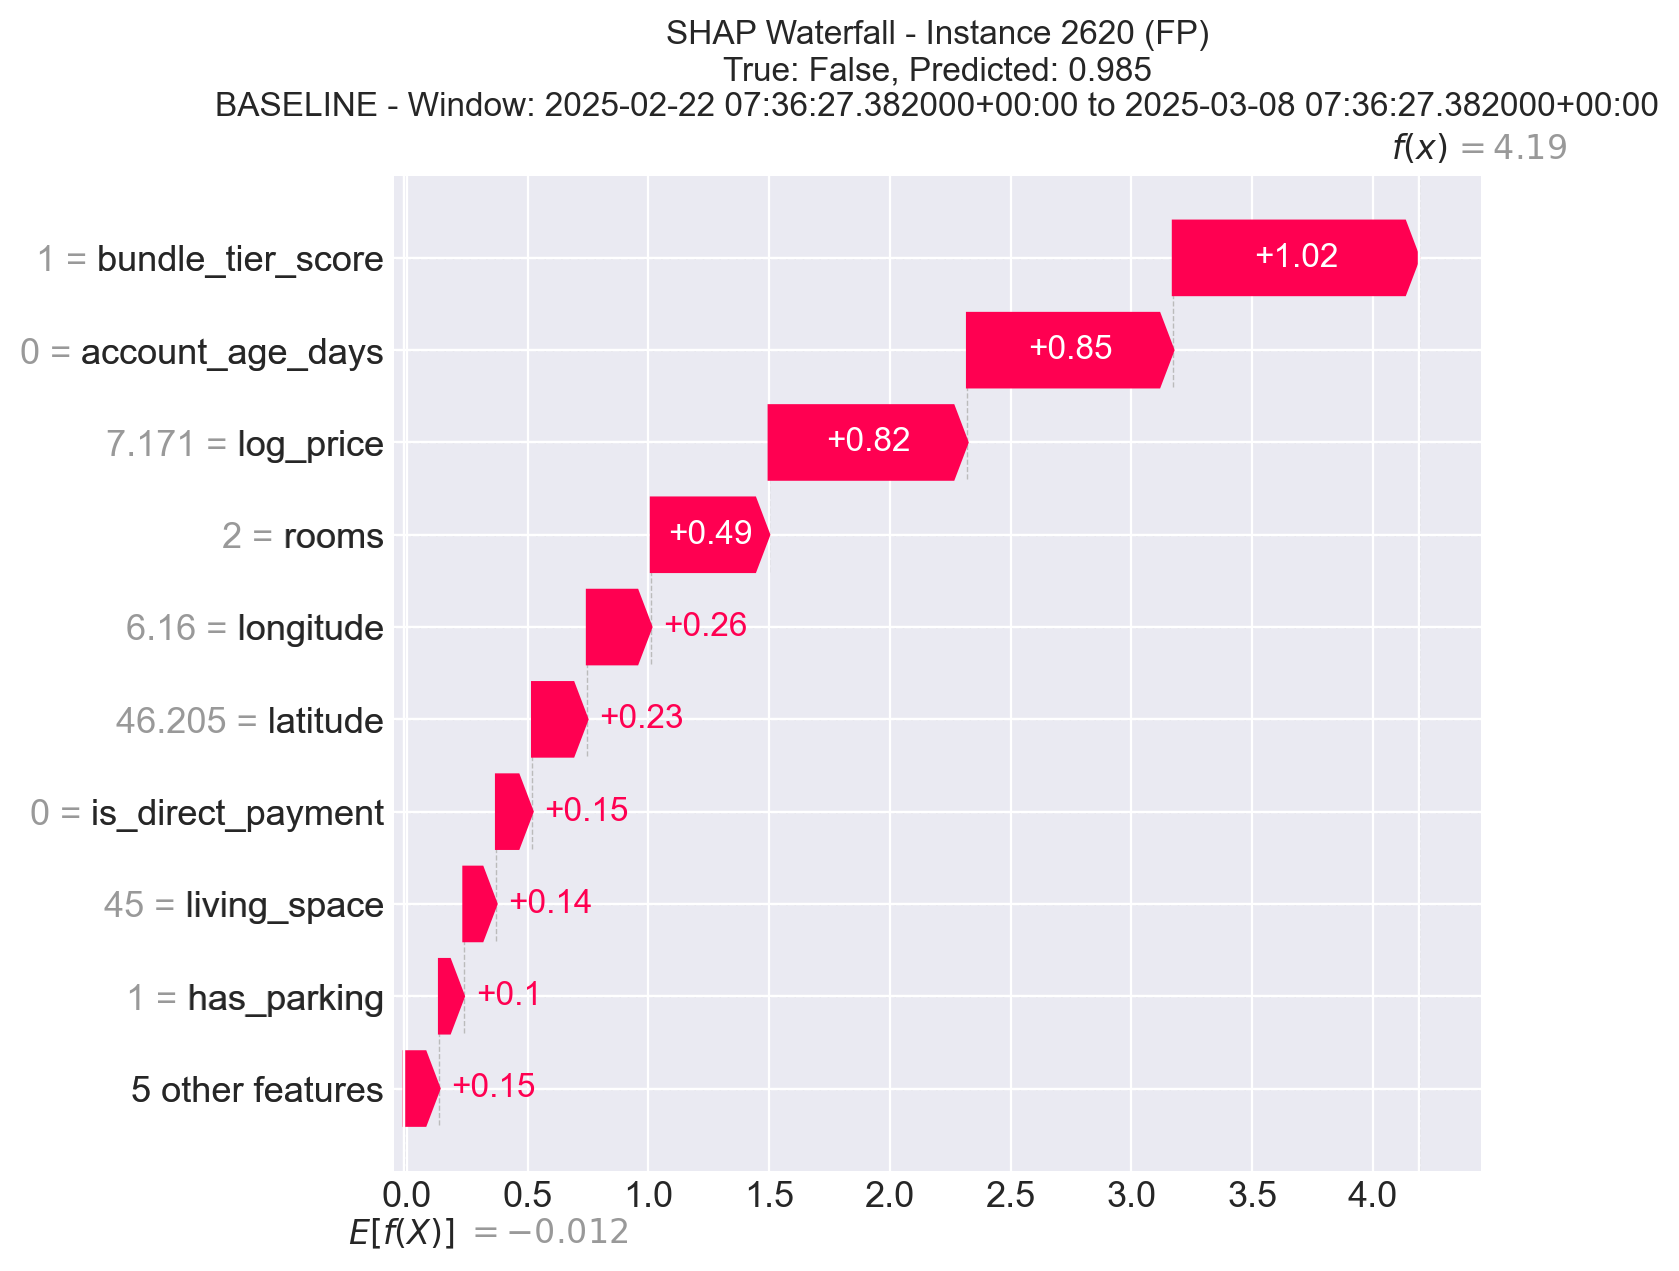


--- False Positive 2 (Index: 3816, Score: 0.9810) ---
Generating waterfall plot for instance 3816...


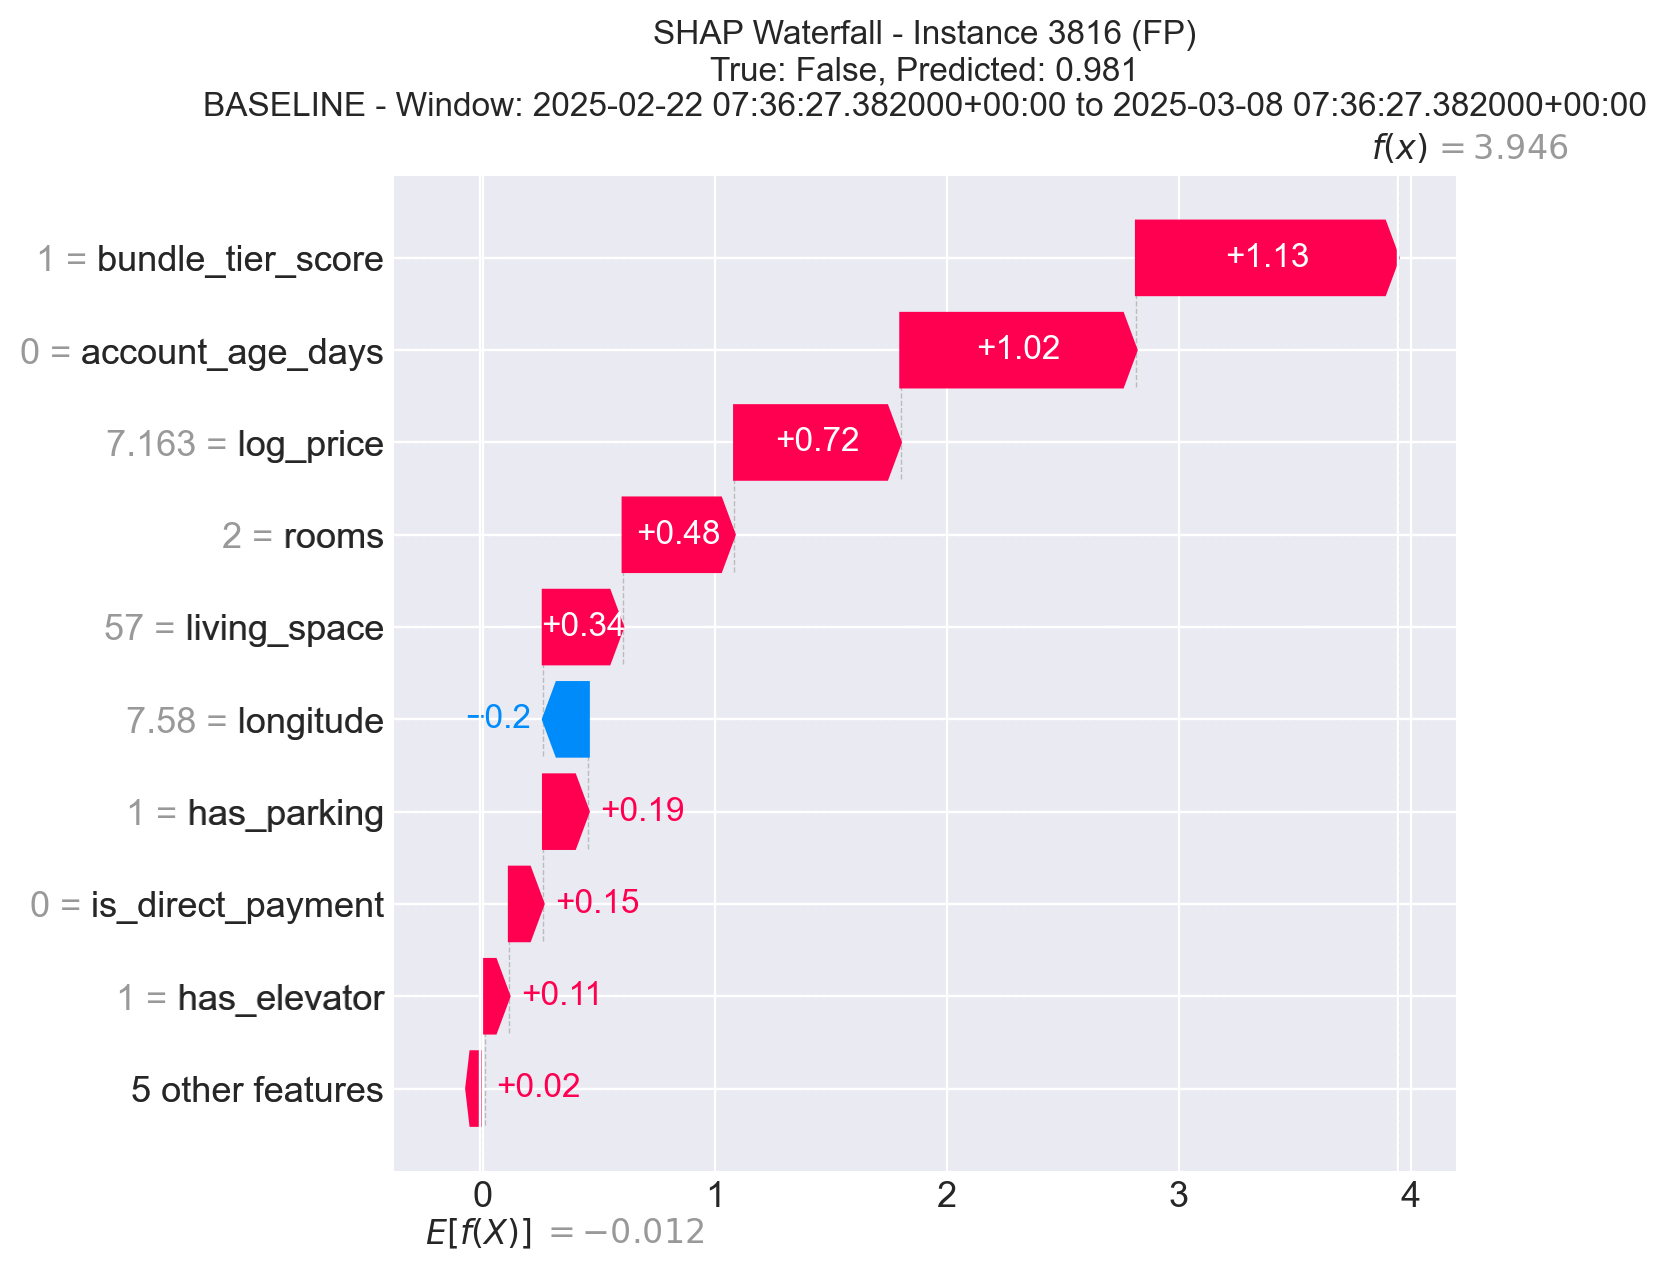


--- False Positive 3 (Index: 2484, Score: 0.9787) ---
Generating waterfall plot for instance 2484...


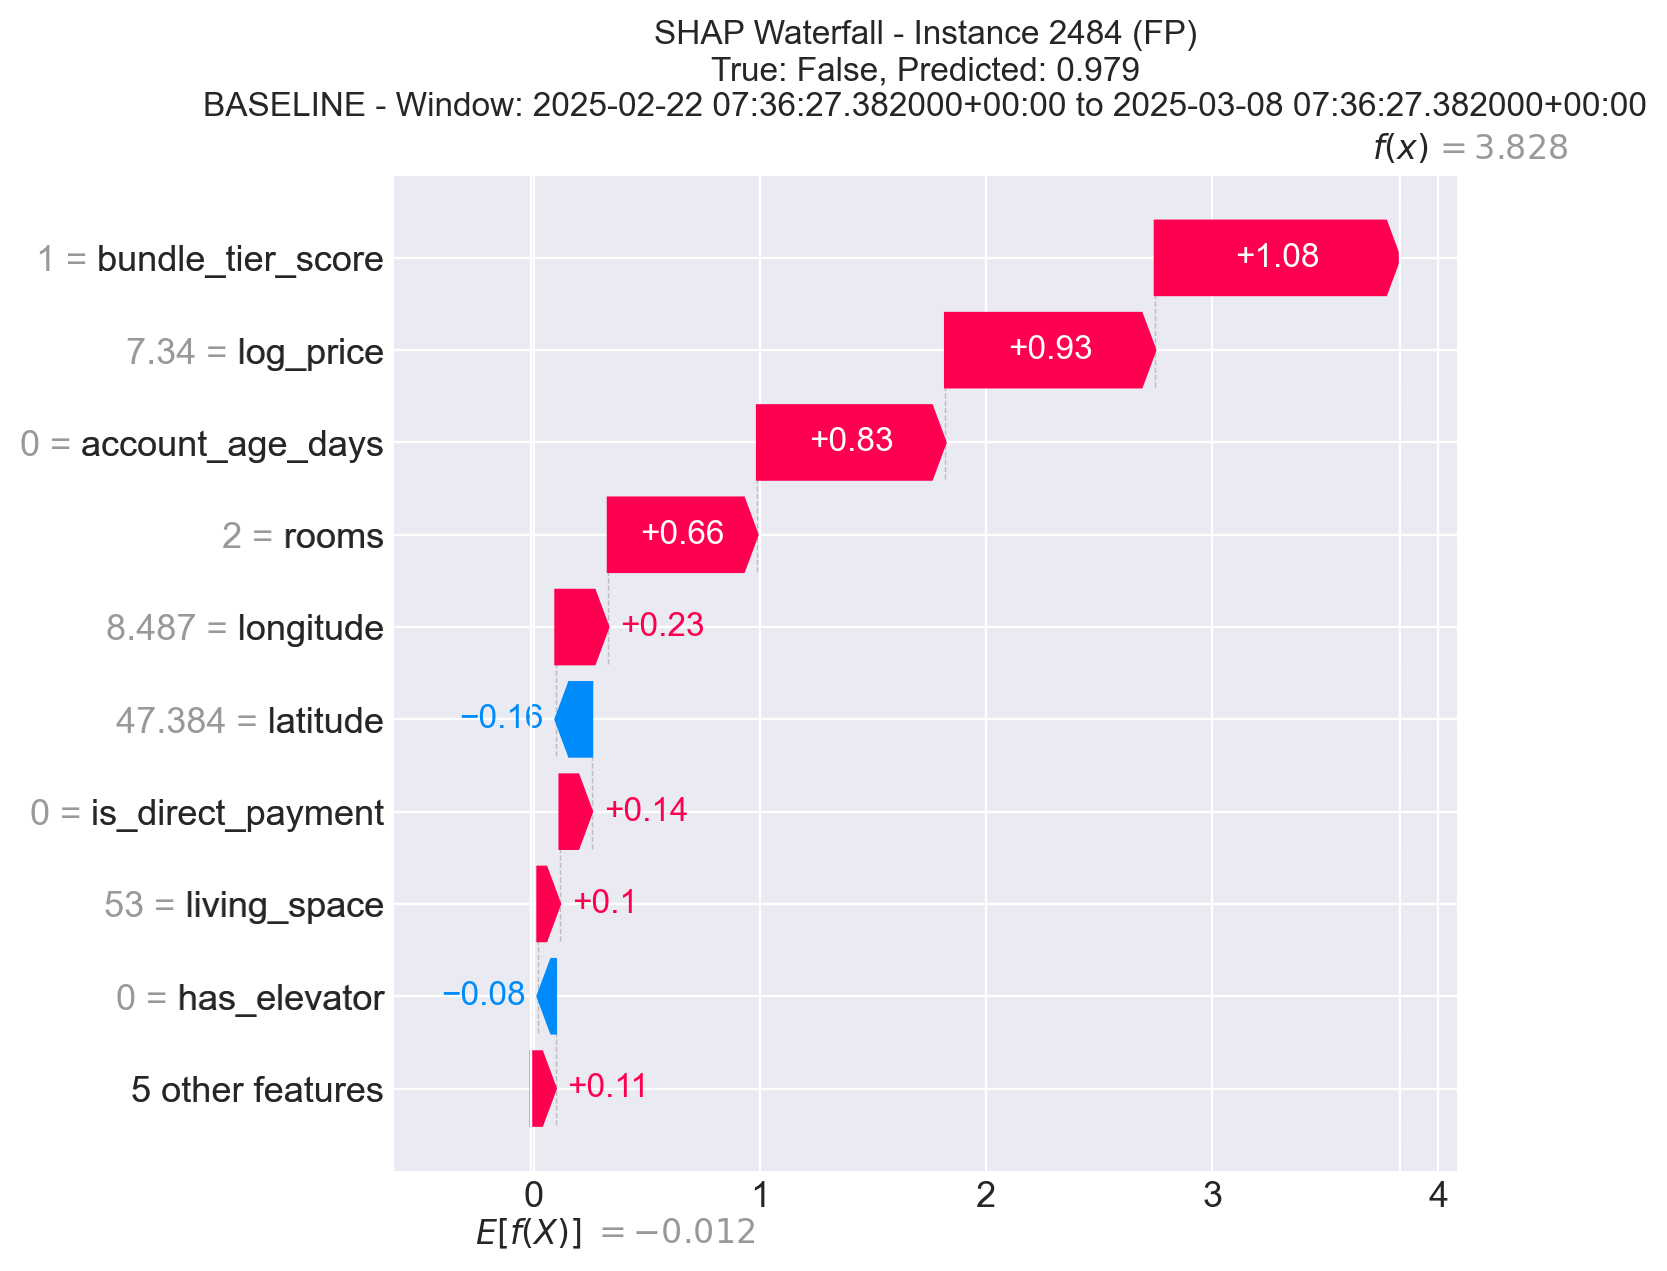


--- False Positive 4 (Index: 3937, Score: 0.9782) ---
Generating waterfall plot for instance 3937...


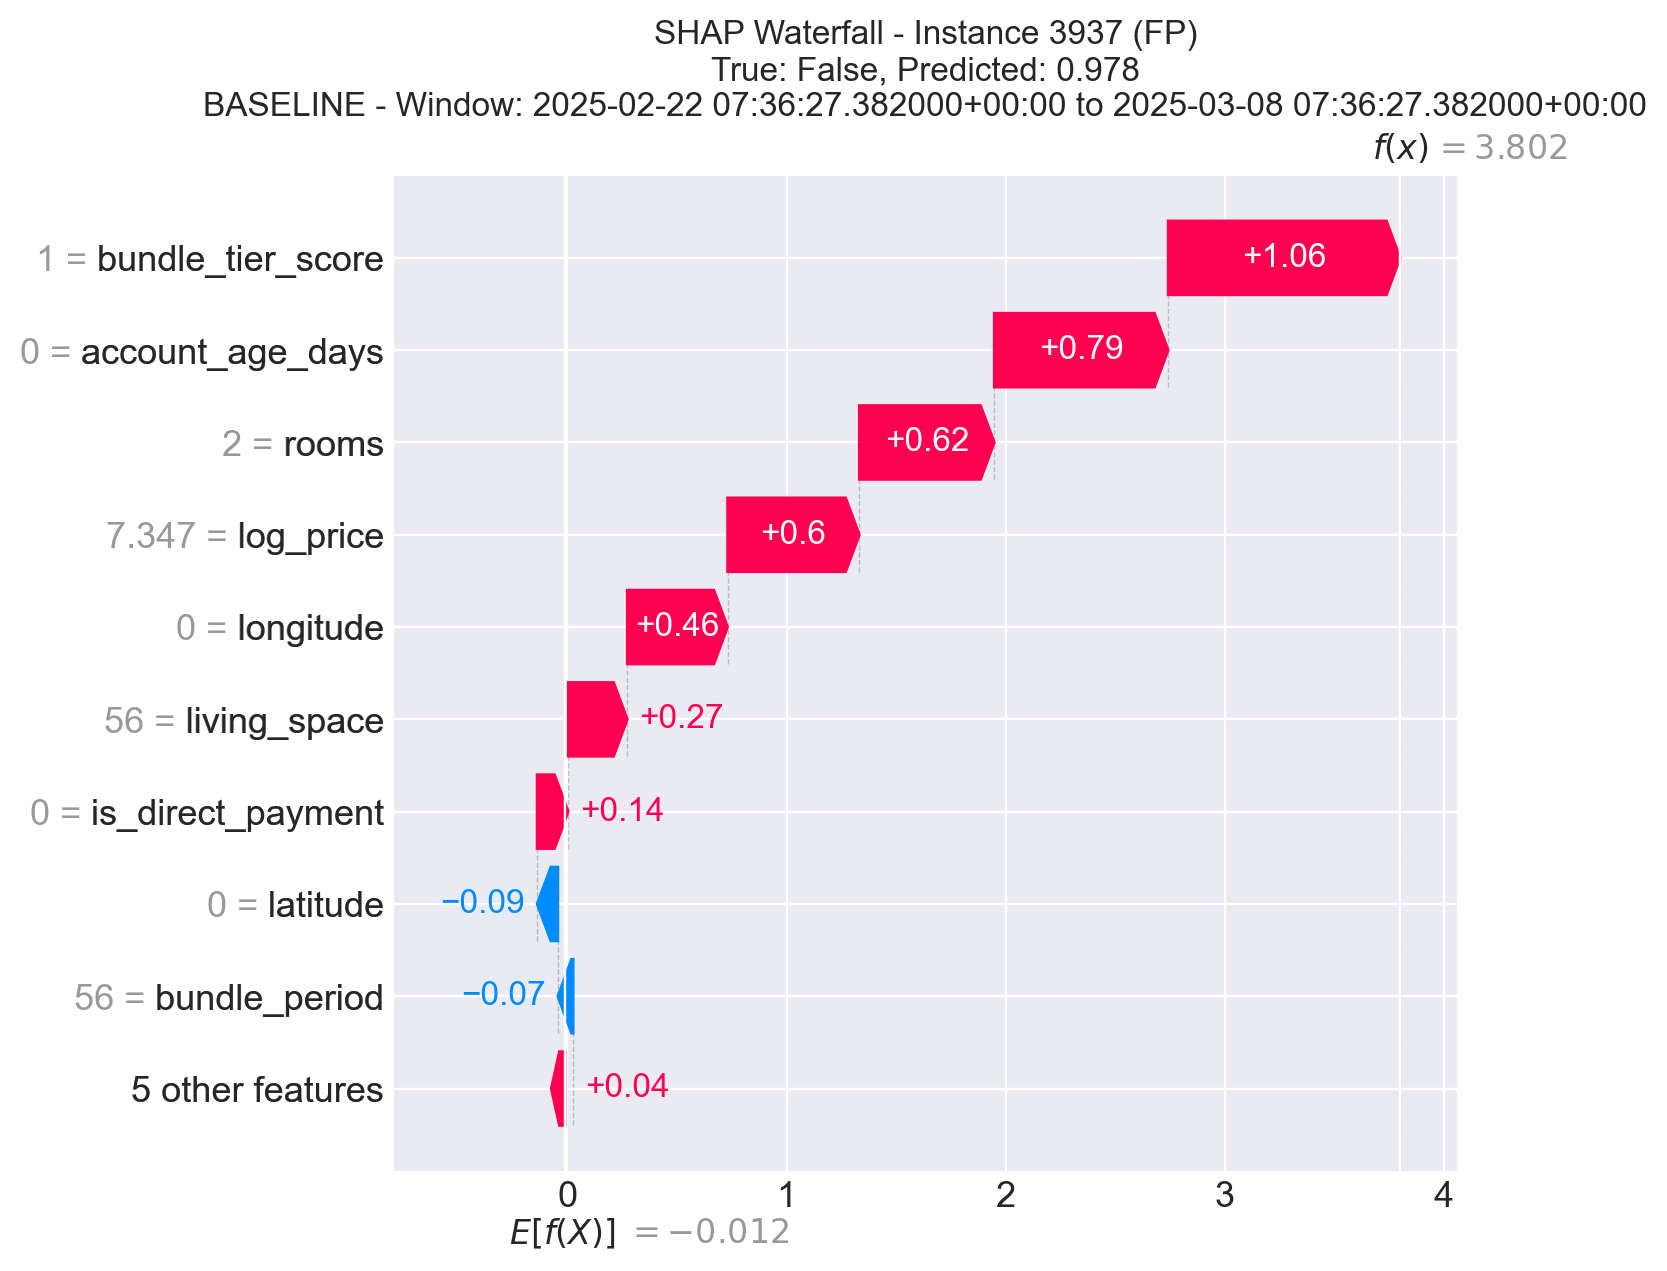


--- False Positive 5 (Index: 634, Score: 0.9732) ---
Generating waterfall plot for instance 634...


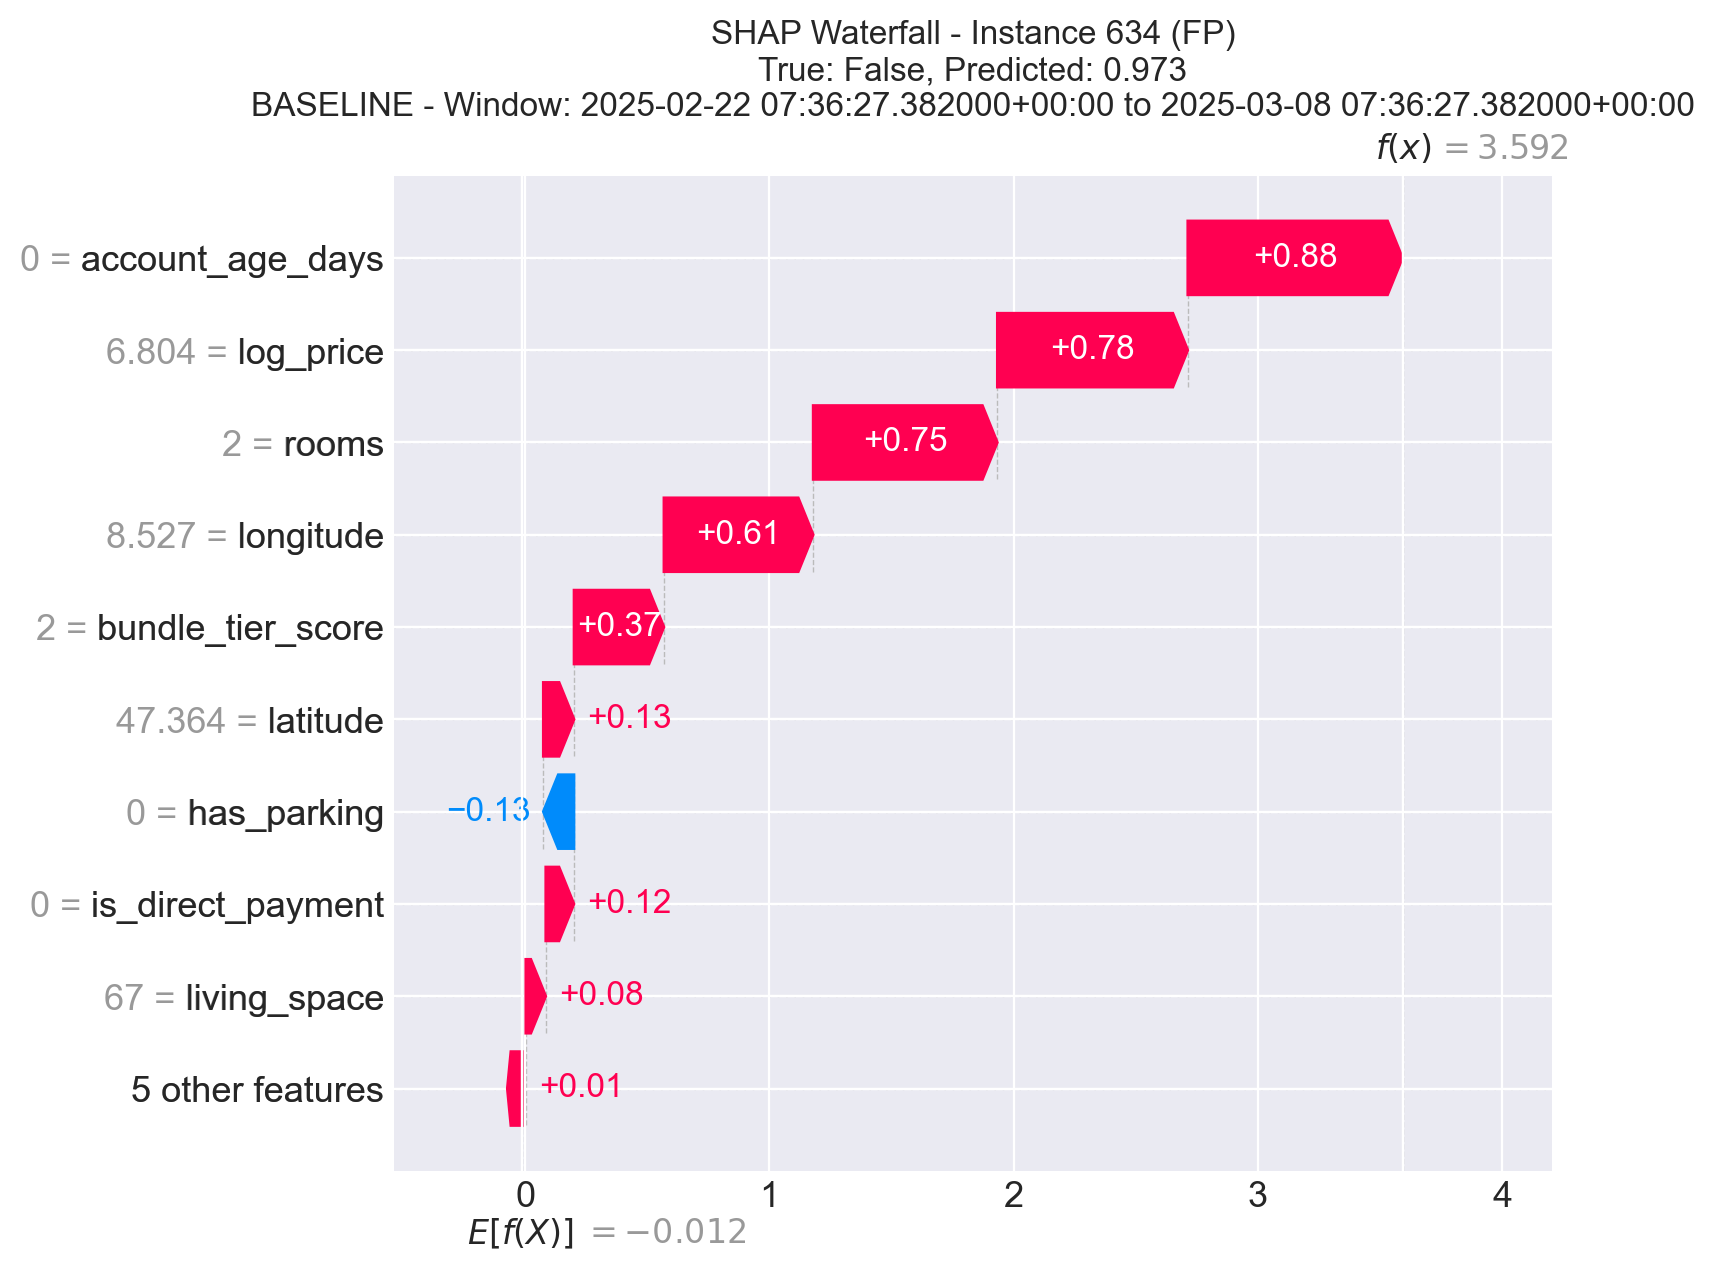

In [ ]:
# Explain top false positives
fp_data = explainer.df_test[explainer.df_test['prediction_type'] == 'FP'].sort_values('y_pred', ascending=False)

if len(fp_data) > 0:
    print(f"Analyzing top 5 false positives out of {len(fp_data)} total")
    for i in range(min(5, len(fp_data))):
        idx = fp_data.index[i]
        print(f"\n--- False Positive {i+1} (Index: {idx}, Score: {fp_data.iloc[i]['y_pred']:.4f}) ---")
        fig = explainer.plot_waterfall(idx, aggregate_embeddings=True)
        plt.show()
else:
    print("No false positives in this window!")


### 5.2 Compare True Positives vs False Positives
What distinguishes correct fraud detections from false alarms?


Comparing TP vs FP...


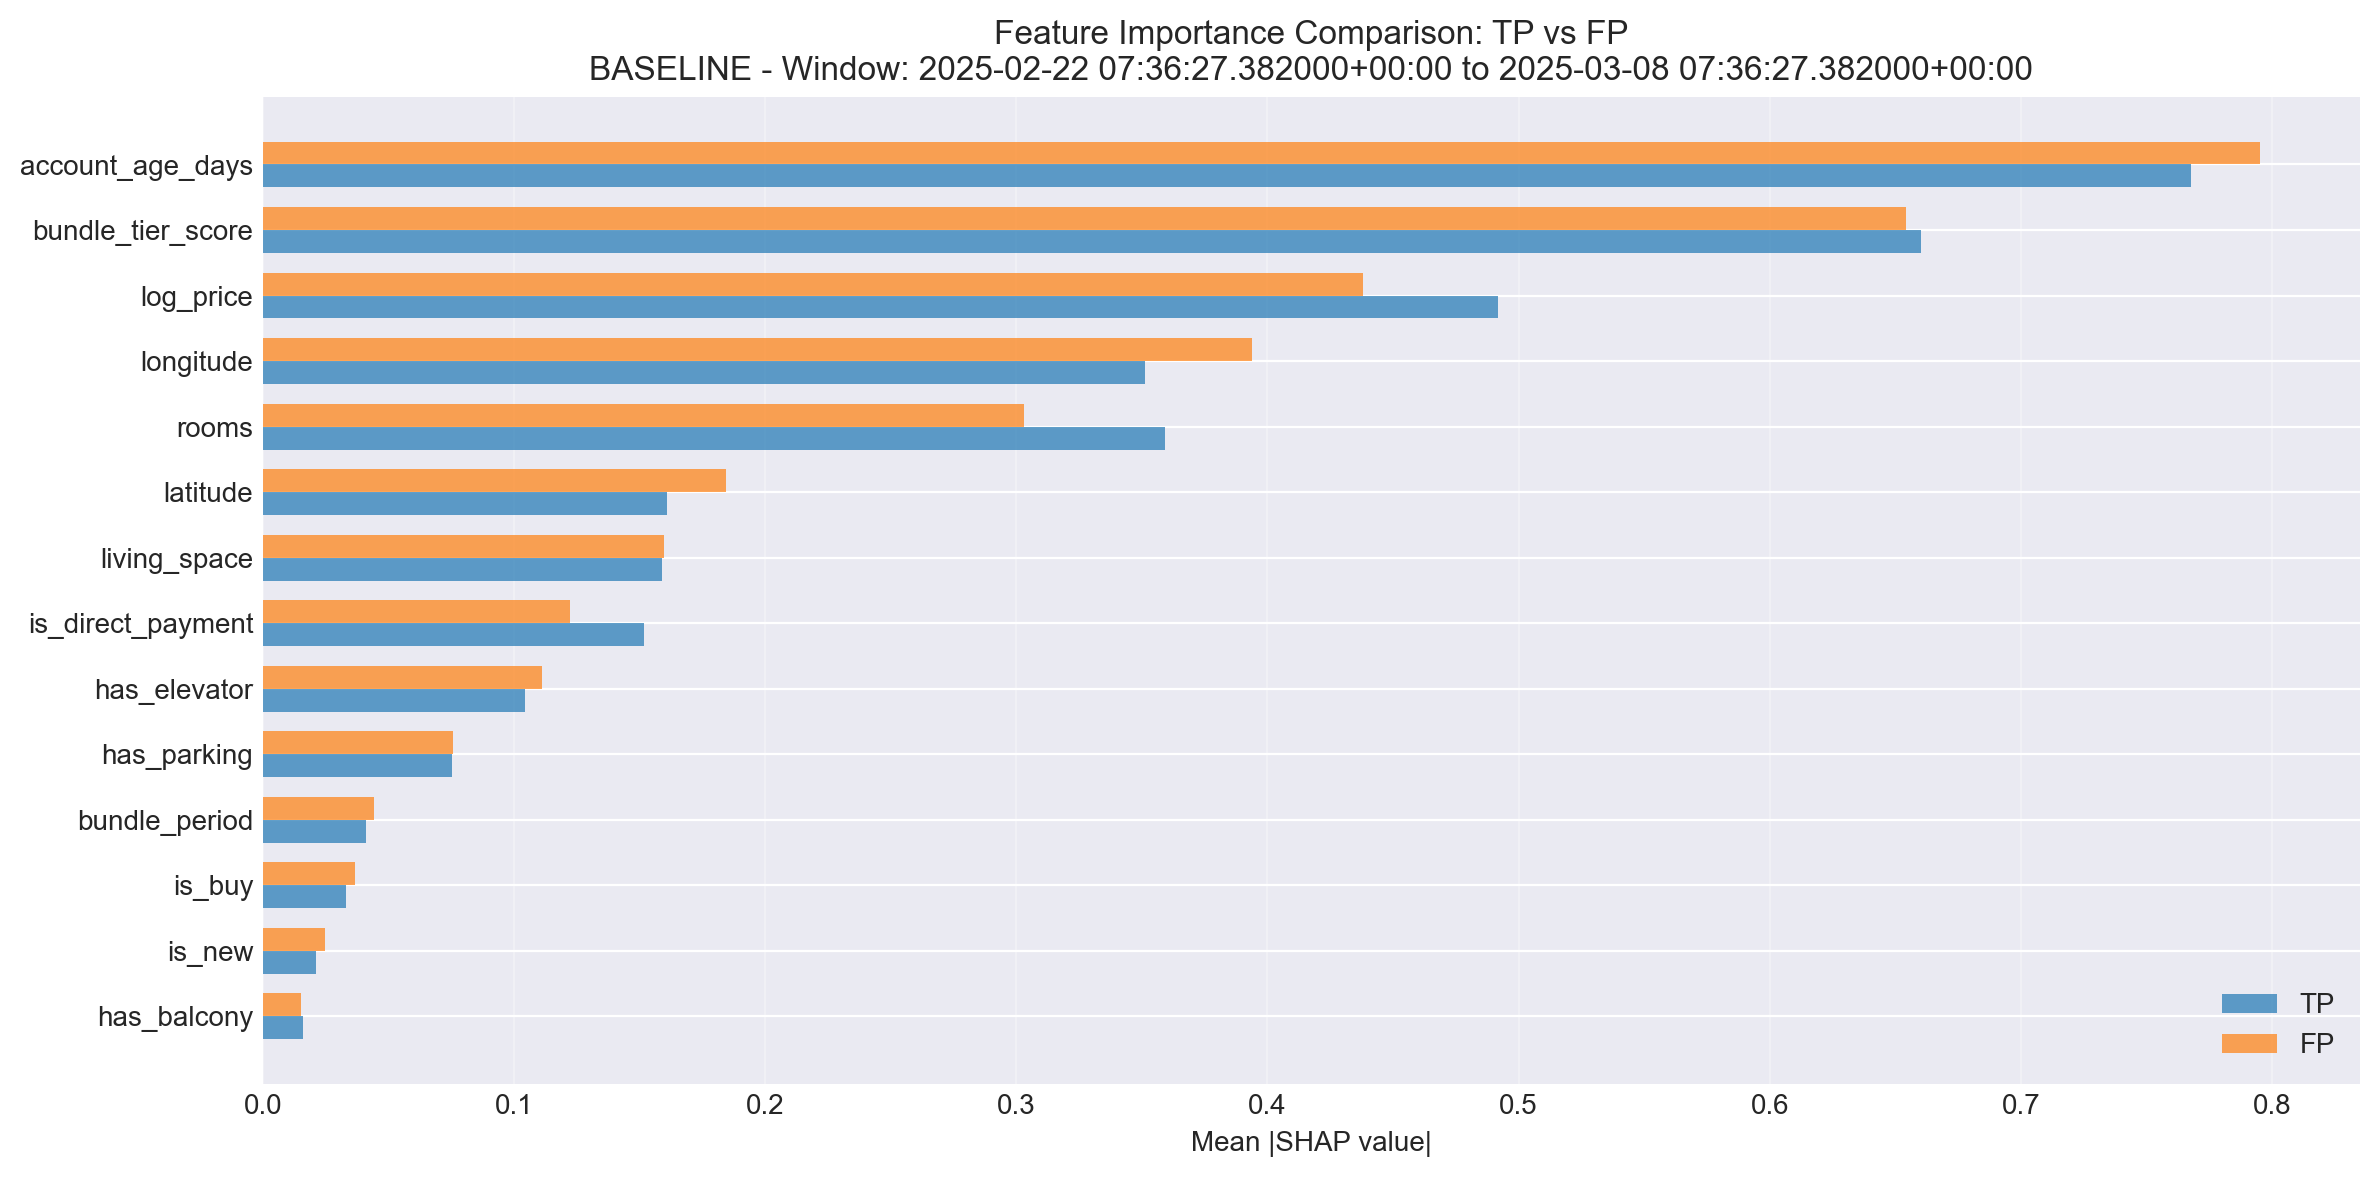

In [ ]:
fig = explainer.analyze_cohort_differences('TP', 'FP', top_n_features=15)
if fig:
    plt.show()
else:
    print("Insufficient data for cohort comparison")


## 6. Model Comparison: Baseline vs Hybrid

**Key Question:** Why doesn't the hybrid model (with GNN embeddings) outperform the baseline?

Let's compare feature importance to see if embeddings are actually useful.


In [ ]:
# Load models for comparison
MODELS_TO_COMPARE = ["baseline", "hybrid_hgt"]  # Adjust based on what you've trained
COMPARISON_WINDOW_IDX = -1  # Use same window for fair comparison

explainers_dict = {}

# Helper function to create explainer (same as in Cell 8)
def create_explainer_from_bundle(bundle, model_type):
    """Create SHAP explainer from model bundle."""
    feature_names = bundle.get('features', list(bundle['X_test'].columns))
    
    # Create TreeExplainer
    explainer_shap = shap.TreeExplainer(bundle['model'])
    
    # Sample if large
    X_test_sample = bundle['X_test']
    if len(X_test_sample) > 1000:
        sample_idx = np.random.choice(len(X_test_sample), 1000, replace=False)
        X_test_sample = X_test_sample.iloc[sample_idx]
        y_test_sample = bundle['y_test'][sample_idx]
        y_pred_sample = bundle['y_pred'][sample_idx]
    else:
        y_test_sample = bundle['y_test']
        y_pred_sample = bundle['y_pred']
    
    # Compute SHAP values
    shap_values = explainer_shap.shap_values(X_test_sample)
    expected_value = explainer_shap.expected_value
    
    # Create SimpleExplainer (same class as Cell 8)
    class SimpleExplainer:
        def __init__(self, shap_values, expected_value, X_test, y_test, y_pred, feature_names):
            self.shap_values = shap_values
            self.expected_value = expected_value
            self.X_test = X_test
            self.y_test = y_test
            self.y_pred = y_pred
            self.feature_names = feature_names
            
            predicted_fraud = (y_pred >= 0.5).astype(int)
            y_true = y_test.astype(int)
            prediction_type = []
            for i in range(len(y_true)):
                if y_true[i] == 1 and predicted_fraud[i] == 1:
                    prediction_type.append('TP')
                elif y_true[i] == 0 and predicted_fraud[i] == 0:
                    prediction_type.append('TN')
                elif y_true[i] == 0 and predicted_fraud[i] == 1:
                    prediction_type.append('FP')
                else:
                    prediction_type.append('FN')
            
            self.df_test = X_test.copy()
            self.df_test['y_true'] = y_true
            self.df_test['y_pred'] = y_pred
            self.df_test['predicted_fraud'] = predicted_fraud
            self.df_test['prediction_type'] = prediction_type
    
    return SimpleExplainer(shap_values, expected_value, X_test_sample, 
                         y_test_sample, y_pred_sample, feature_names)

# Load each model from MLflow
for model_type in MODELS_TO_COMPARE:
    print(f"Loading {model_type} from MLflow...")
    
    # Load model bundle from MLflow
    bundle = load_model_bundle(model_type, COMPARISON_WINDOW_IDX)
    
    if bundle is None:
        print(f"⚠️ Model not found in MLflow for {model_type}. Skipping.")
        continue
    
    # Load test data (same as Cell 7)
    from src.models.train_baseline import load_data, feature_engineering, get_base_features
    
    df = load_data()
    include_graph = model_type in ["baseline_graph", "hybrid_hgt", "hybrid_gat", "hybrid_sage", "hybrid_hgt_rte"]
    df = feature_engineering(df, include_graph_features=include_graph)
    
    # Get feature list
    all_graph_cols = (
        ["contact_email_count", "shared_contact_email_count", "max_shared_contact_email",
         "contact_phone_count", "shared_contact_phone_count", "max_shared_contact_phone",
         "user_listing_count", "user_unique_ip_count", "shared_ip_user_count",
         "max_shared_ip_users", "listing_component_size", "listing_pagerank",
         "degree_total", "is_isolated", "unique_identifier_count",
         "neighbor_overlap_score", "avg_neighbor_degree"] +
        ["email_total_historical", "email_count_7d", "email_count_30d",
         "email_recent_weighted", "email_velocity_7d", "email_acceleration",
         "email_is_burst", "email_is_dormant_reactivation", "email_recency_weighted",
         "email_time_spread", "phone_total_historical", "phone_count_7d",
         "phone_count_30d", "phone_recent_weighted", "phone_velocity_7d",
         "phone_acceleration", "phone_is_burst", "phone_is_dormant_reactivation",
         "phone_recency_weighted", "phone_time_spread", "combined_velocity_7d",
         "combined_acceleration", "any_burst", "any_dormant_reactivation",
         "combined_recency_weighted"] +
        ["new_account_high_email_reuse", "new_account_high_phone_reuse",
         "new_account_high_reuse_any", "new_account_invoice_payment",
         "very_new_account_invoice", "is_small_listing", "new_account_small_listing",
         "in_large_component", "new_account_large_component", "new_account_isolated",
         "account_age_risk_score", "email_reuse_intensity", "component_risk_score",
         "suspicious_combo_score"]
    )
    graph_columns = [col for col in all_graph_cols if col in df.columns]
    features = get_base_features() + graph_columns
    
    # Filter test data
    test_start = pd.to_datetime(bundle['window_info']['test_start'])
    test_end = pd.to_datetime(bundle['window_info']['test_end'])
    
    df_test = df.filter(
        (pl.col("submission_at") >= test_start) &
        (pl.col("submission_at") < test_end)
    ).sort("submission_at")
    
    # Prepare features and target
    X_test = df_test.select(features).to_pandas()
    y_test = df_test["is_fraud"].to_numpy()
    y_pred = bundle['model'].predict_proba(X_test)[:, 1]
    
    # Add to bundle
    bundle['X_test'] = X_test
    bundle['y_test'] = y_test
    bundle['y_pred'] = y_pred
    
    # Create explainer
    exp = create_explainer_from_bundle(bundle, model_type)
    explainers_dict[model_type] = exp
    
    print(f"  Window: {bundle['window_info']['window_idx']}")
    print(f"  AUC-PR: {bundle['metrics']['auc_pr']:.4f}")
    print(f"  P@100: {bundle['metrics'].get('p@100', bundle['metrics'].get('p_at_100', 0)):.4f}")
    print(f"  Test size: {len(y_test):,}")

print(f"\n✓ Loaded {len(explainers_dict)} models for comparison")


Loading baseline: model_window_99.pkl
Checking model integrity and fixing if needed...
✓ Model parameters normalized successfully
Initializing SHAP TreeExplainer...
Computing SHAP values...
  AUC-PR: 0.5914
  P@100: 0.7700
  Test size: 3,976
Loading hybrid_hgt: model_window_9.pkl
Checking model integrity and fixing if needed...
✓ Model parameters normalized successfully
Initializing SHAP TreeExplainer...
Computing SHAP values...
  AUC-PR: 0.6305
  P@100: 0.7400
  Test size: 2,555

✓ Loaded 2 models for comparison


Comparing 2 models...


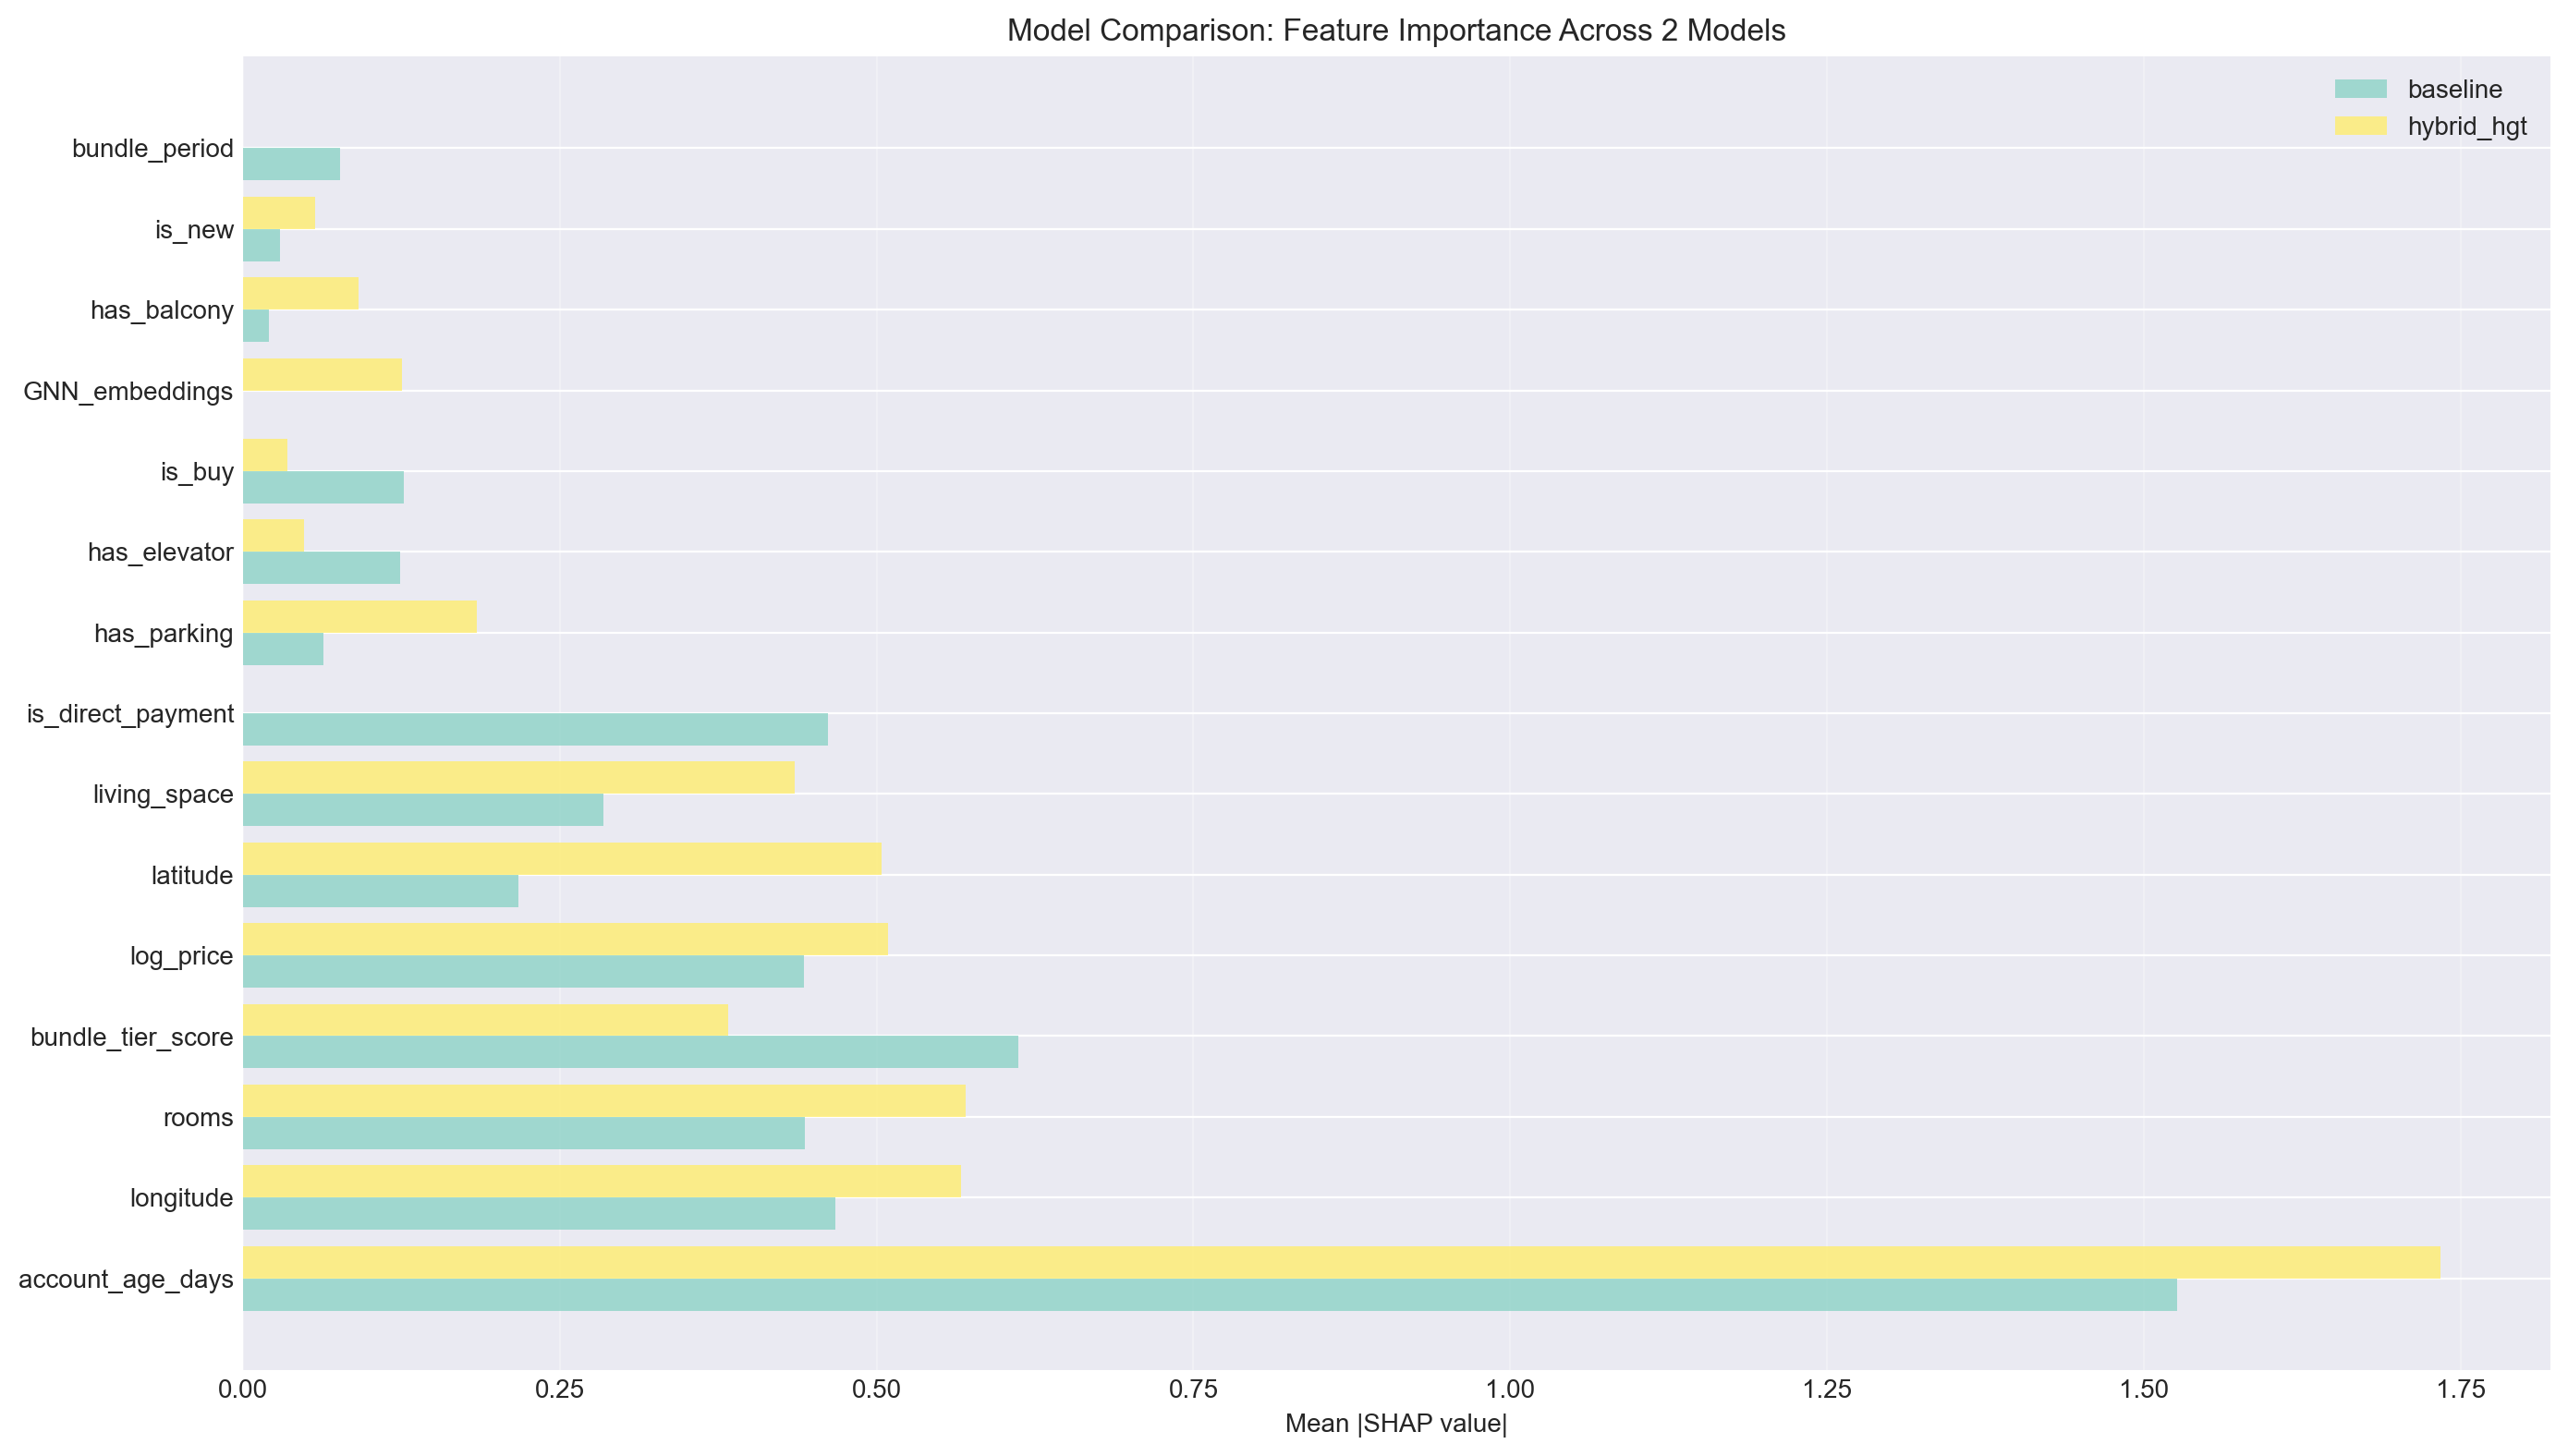

In [ ]:
# Generate comparison plot using SHAP
if len(explainers_dict) >= 2:
    # Create a simple comparison by plotting feature importance side-by-side
    fig, axes = plt.subplots(1, len(explainers_dict), figsize=(8 * len(explainers_dict), 6))
    if len(explainers_dict) == 1:
        axes = [axes]
    
    for idx, (model_name, explainer) in enumerate(explainers_dict.items()):
        # Calculate mean absolute SHAP values (feature importance)
        mean_shap = np.abs(explainer.shap_values).mean(0)
        
        # Get top features
        top_n = 15
        top_indices = np.argsort(mean_shap)[-top_n:][::-1]
        top_features = [explainer.feature_names[i] for i in top_indices]
        top_values = mean_shap[top_indices]
        
        # Plot
        axes[idx].barh(range(len(top_features)), top_values)
        axes[idx].set_yticks(range(len(top_features)))
        axes[idx].set_yticklabels(top_features)
        axes[idx].set_xlabel('Mean |SHAP Value|')
        axes[idx].set_title(f'{model_name.upper()} - Top {top_n} Features')
        axes[idx].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    print(f"✓ Compared {len(explainers_dict)} models")
else:
    print("Need at least 2 models to compare. Train additional models with MLflow tracking.")


### 6.1 Embedding Contribution Analysis

For hybrid models, let's specifically examine how much the GNN embeddings contribute.


Analyzing embedding contribution in hybrid_hgt

Found 64 embedding features

Embedding Contribution Statistics:
  Mean absolute embedding SHAP: 0.004313
  Mean absolute total SHAP: 0.069166
  Embedding contribution: 6.24%


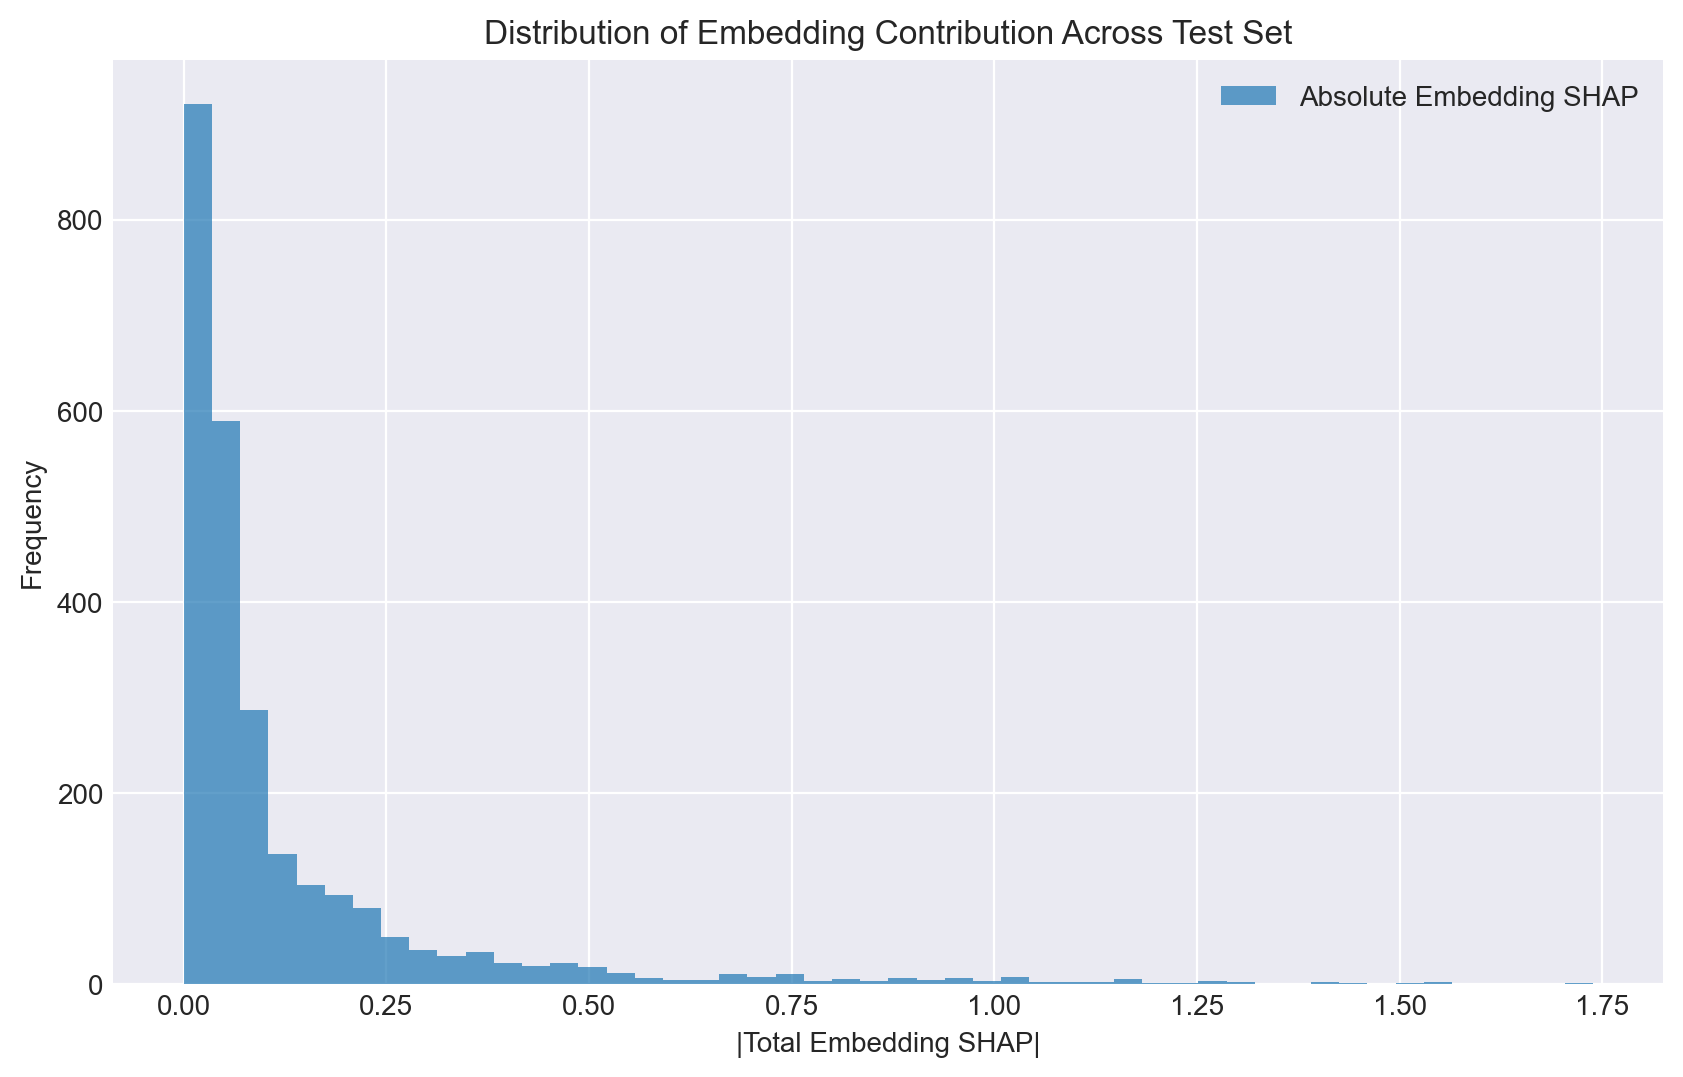

In [ ]:
# Check if we have a hybrid model loaded
hybrid_explainer = None
for name, exp in explainers_dict.items():
    if 'hybrid' in name:
        hybrid_explainer = exp
        hybrid_name = name
        break

if hybrid_explainer:
    print(f"Analyzing embedding contribution in {hybrid_name}")
    
    # Get embedding features
    embed_features = hybrid_explainer._get_embedding_features()
    print(f"\nFound {len(embed_features)} embedding features")
    
    # Calculate total embedding contribution
    embed_indices = [i for i, name in enumerate(hybrid_explainer.feature_names) if name in embed_features]
    embed_shap = hybrid_explainer.shap_values[:, embed_indices]
    
    # Total embedding SHAP per instance
    total_embed_shap = np.sum(embed_shap, axis=1)
    
    # Statistics
    print(f"\nEmbedding Contribution Statistics:")
    print(f"  Mean absolute embedding SHAP: {np.abs(embed_shap).mean():.6f}")
    print(f"  Mean absolute total SHAP: {np.abs(hybrid_explainer.shap_values).mean():.6f}")
    print(f"  Embedding contribution: {np.abs(embed_shap).mean() / np.abs(hybrid_explainer.shap_values).mean() * 100:.2f}%")
    
    # Distribution plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(np.abs(total_embed_shap), bins=50, alpha=0.7, label='Absolute Embedding SHAP')
    ax.set_xlabel('|Total Embedding SHAP|')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Embedding Contribution Across Test Set')
    ax.legend()
    plt.show()
else:
    print("No hybrid model found. Train a hybrid model with: python -m src.cli train-hybrid --save-models")


## 7. Export Results

Save all visualizations and feature importance tables for reporting.


In [ ]:
# Export all SHAP visualizations for the current model
if 'explainer' in locals() and 'model_bundle' in locals():
    window_idx = model_bundle['window_info'].get('window_idx', 'unknown')
    output_dir = project_root / "artifacts" / "shap" / MODEL_TYPE / f"window_{window_idx}"
    
    print(f"Saving all SHAP visualizations to {output_dir}...")
    save_explainer(explainer, str(output_dir), prefix="")
    print("✓ Export complete!")
else:
    print("No explainer loaded. Run the cells above first.")


Saving all SHAP visualizations to /Users/dylan/Repos/ppa-fraud-notebook/artifacts/shap/baseline/window_99...

Generating all SHAP visualizations in /Users/dylan/Repos/ppa-fraud-notebook/artifacts/shap/baseline/window_99...
Generating SHAP summary plot...
Saved summary plot to /Users/dylan/Repos/ppa-fraud-notebook/artifacts/shap/baseline/window_99/summary_plot.png
Generating feature importance bar chart...
Saved feature importance bar chart to /Users/dylan/Repos/ppa-fraud-notebook/artifacts/shap/baseline/window_99/feature_importance.png
Explaining top 10 FP predictions...
Generating waterfall plot for instance 2620...
Saved waterfall plot to /Users/dylan/Repos/ppa-fraud-notebook/artifacts/shap/baseline/window_99/fp_explanations/FP_instance_0_idx2620.png
Generating waterfall plot for instance 3816...
Saved waterfall plot to /Users/dylan/Repos/ppa-fraud-notebook/artifacts/shap/baseline/window_99/fp_explanations/FP_instance_1_idx3816.png
Generating waterfall plot for instance 2484...
Saved

## 8. Adaptation Engine Integration

Use the Adaptation Engine to automatically generate insights from SHAP analysis.


In [ ]:
# Run Adaptation Engine on current model
from src.explainability.adaptation_engine import AdaptationEngine

if 'model_bundle' in locals():
    # Initialize engine with feature names
    engine = AdaptationEngine(
        feature_names=model_bundle['features'],
        history_window=5,
        drift_rank_threshold=5,
        prune_importance_threshold=0.001,
    )
    
    # Analyze the current window
    report = engine.analyze_window(
        model=model_bundle['model'],
        X_test=model_bundle['X_test'],
        y_test=model_bundle['y_test'],
        y_pred=model_bundle['y_pred'],
        window_info=model_bundle['window_info']
    )
    
    # Display results
    print("="*60)
    print("ADAPTATION REPORT")
    print("="*60)
    print(f"\nWindow: {report.window_idx}")
    print(f"AUC-PR: {report.model_performance.get('auc_pr', 0):.4f}")
    print(f"AUC-ROC: {report.model_performance.get('auc_roc', 0):.4f}")
    print(f"Precision: {report.model_performance.get('precision', 0):.4f}")
    print(f"Recall: {report.model_performance.get('recall', 0):.4f}")
    
    print(f"\n📊 Drift Alerts: {len(report.drift_alerts)}")
    for alert in report.drift_alerts[:3]:
        # DriftAlert is a dataclass, access attributes directly
        print(f"   - {alert.feature}: rank {alert.previous_rank} → {alert.current_rank}")
    
    print(f"\n📈 Rising Features: {len(report.rising_features)}")
    for feat in report.rising_features[:3]:
        print(f"   - {feat.feature}: +{feat.importance_delta:.4f}")
    
    print(f"\n📉 Falling Features: {len(report.falling_features)}")
    for feat in report.falling_features[:3]:
        print(f"   - {feat.feature}: {feat.importance_delta:.4f}")
    
    print(f"\n🗑️ Pruning Candidates: {len(report.pruning_candidates)}")
    if report.pruning_candidates:
        print(f"   {report.pruning_candidates[:5]}")
    
    print(f"\n💡 Rule Suggestions: {len(report.rule_suggestions)}")
    for rule in report.rule_suggestions[:2]:
        print(f"   - {rule.title} ({rule.priority})")
        print(f"     Impact: {rule.expected_impact}")
    
    print(f"\n🔄 Retrain Recommended: {'Yes ⚠️' if report.retrain_recommendation else 'No ✅'}")
else:
    print("Load a model first (run cells above)")


[Adaptation] Analyzing window 99...
[Adaptation] Computing SHAP values...
[Adaptation] Generating rule suggestions...
[Adaptation] Analysis complete. 1 rules suggested.
ADAPTATION REPORT

Window: 99
AUC-PR: 0.5914
AUC-ROC: 0.9136
Precision: 0.4412
Recall: 0.7933

📊 Drift Alerts: 8
   - account_age_days: rank 14 → 1
   - log_price: rank 14 → 6
   - living_space: rank 14 → 7

📈 Rising Features: 8
   - account_age_days: +0.3118
   - log_price: +0.0905
   - living_space: +0.0582

📉 Falling Features: 0

🗑️ Pruning Candidates: 0

💡 Rule Suggestions: 1
   - High-risk pattern: bundle_tier_score (medium)
     Impact: 3.1x lift over baseline (34.4% fraud rate)

🔄 Retrain Recommended: Yes ⚠️


### 8.1 View Recent Adaptation Reports

Load and display adaptation reports from the continuous pipeline.


In [ ]:
# View recent adaptation reports
from pathlib import Path

reports_dir = project_root / "artifacts" / "reports"
adaptation_reports = sorted(reports_dir.glob("adaptation_report_*.md"))[-5:]

if adaptation_reports:
    print("Recent Adaptation Reports:")
    print("="*60)
    for report_path in adaptation_reports:
        print(f"\n📄 {report_path.name}")
        
        # Read first few lines
        with open(report_path) as f:
            lines = f.readlines()[:15]
            for line in lines:
                print(f"   {line.rstrip()}")
            if len(lines) == 15:
                print("   ...")
else:
    print("No adaptation reports found.")
    print("Run: make analyze-adaptation-all")


Recent Adaptation Reports:

📄 adaptation_report_window_68.md
   # Adaptation Report - Window 68
   
   **Generated**: 2025-11-26 09:46:45
   
   ## Model Performance
   - **auc_pr**: 0.5400
   - **auc_roc**: 0.9407
   - **precision**: 0.4254
   - **recall**: 0.8118
   - **fraud_count**: 186
   - **test_size**: 2730
   - **p@50**: 0.6000
   - **p@100**: 0.6800
   - **p@200**: 0.5800
   
   ...

📄 adaptation_report_window_7.md
   # Adaptation Report - Window 7
   
   ## Model Performance
   - **AUC-PR**: 0.8198
   - **P@100**: 0.9900
   
   ## Drift Alerts (Rising Stars)
   No significant feature drift detected.
   
   ## Top 10 Features
   - **bundle_period**: 0.0787
   - **price_rent_gross**: 0.0329
   - **bundle_tier**: 0.0272
   - **user_listing_count**: 0.0245
   - **num_floors**: 0.0226
   ...

📄 adaptation_report_window_8.md
   # Adaptation Report - Window 8
   
   ## Model Performance
   - **AUC-PR**: 0.8817
   - **P@100**: 0.9900
   
   ## Drift Alerts (Rising Stars)
   No signi

## 9. Next Steps for Continuous Learning

### Automated Pipeline

```bash
# Start the continuous pipeline scheduler
make pipeline-start

# Or run individual jobs manually:
make pipeline-daily      # Drift check
make pipeline-weekly     # Retrain evaluation
make pipeline-monthly    # Hyperparameter optimization
```

### Manual Analysis

1. **Compare windows over time**: Analyze feature importance stability across multiple windows
2. **Investigate drift**: When adaptation engine flags drift, use SHAP to understand what changed
3. **Validate rule suggestions**: Test proposed rules on held-out data before deployment
4. **Track MLflow experiments**: Use `make mlflow-ui` to compare model versions

### Documentation

- Framework overview: `docs/continuous_fraud_detection_framework.md`
- Experiment history: `docs/experiment_journal.md`
- Integration architecture: `docs/integration_architecture.md`
